<h1 align="center"><strong>Precipitation Variability and Extreme Events in the Western Mediterranean</strong></h1>
<h2 align="center">A Regional Climate Analysis Using CHIRPS (1981–2023)</h2>

## 1. Introduction

<div style="text-align: justify;">
Precipitation extremes represent one of the most consequential expressions of climate variability and change. Unlike gradual shifts in mean temperature, extreme precipitation events drive the majority of climate-related damages through flooding, agricultural disruption, and water resource 
stress. Understanding how these extremes are distributed in space and time, how they relate to large-scale atmospheric circulation, and whether they are changing in response to anthropogenic forcing.

The Western Mediterranean is one of the most climatologically sensitive regions on Earth. Positioned at the intersection of the mid-latitude westerly belt and the subtropical dry zone, it is subject to a pronounced seasonal precipitation regime and to some of the most intense convective precipitation events in Europe, concentrated in autumn when warm sea surface temperatures and cold continental air intrusions combine to produce explosive convective instability.

Detecting and attributing these changes from observations alone remains challenging. The region's precipitation variability is dominated by internal climate modes, particularly the North Atlantic Oscillation (NAO), which controls the meridional position of the winter jet stream and explains a substantial fraction of interannual winter precipitation variance, which can mask forced trends over records of several decades. Disentangling the circulation-driven component of precipitation variability from the thermodynamic response to greenhouse gas forcing is the central methodological challenge of Mediterranean precipitation attribution, and one that requires both careful observational analysis and counterfactual model ensembles.

This project conducts a systematic attribution-oriented analysis of precipitation variability and extreme events in the Western Mediterranean (35°N–47°N, 10°W–15°E) using CHIRPS v2.0 daily precipitation (1981–2023), four ETCCDI extreme indices, NAO circulation composites, non-stationary GEV models with a GMST covariate, and the IPSL-CM6A-LR CMIP6 historical and hist-nat ensembles. The central question motivating the analysis is whether the competing mechanisms of regional drying and thermodynamic intensification produce a detectable and attributable signal in the tails of the precipitation distribution and if so, at what intensity threshold anthropogenic forcing shifts from reducing to increasing event probability.

---

**Data:** CHIRPS v2.0 | 0.25° | Daily | 1981–2023  
**Region:** Western Mediterranean | 35°N–47°N, 10°W–15°E  
**Tools:** xarray, scipy, pymannkendall, cartopy, matplotlib  
**Indices:** Rx1day, R95p, SDII, CDD (ETCCDI), NAO (NOAA CPC)

</div>

## 2. Importing and inspecting the dataset

In [1]:
## Required libraries
from scipy.stats import genextreme, ks_2samp
from scipy.optimize import minimize
import cartopy.feature as cfeature
import matplotlib.lines as lines
import matplotlib.pyplot as plt
from scipy.stats import chi2
import cartopy.crs as ccrs
import pymannkendall as mk
from scipy import stats
import pandas as pd
import xarray as xr
import numpy as np
import tempfile
import requests
import warnings
import pooch
import scipy
import s3fs
import glob
import os

In [2]:
# Local data folder
DATA_DIR = r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\Data"

# All CHIRPS files downloaded 
downloaded_files = sorted(glob.glob(os.path.join(DATA_DIR, "chirps-v2.0.*.days_p25.nc")))

# Verification
print(f"Found {len(downloaded_files)} files")
print(f"First: {os.path.basename(downloaded_files[0])}")
print(f"Last:  {os.path.basename(downloaded_files[-1])}")

Found 43 files
First: chirps-v2.0.1981.days_p25.nc
Last:  chirps-v2.0.2023.days_p25.nc


In [3]:
# Importing the full dataset
chirps_data = xr.open_mfdataset(downloaded_files,combine="by_coords")

print(chirps_data)

<xarray.Dataset> Size: 36GB
Dimensions:    (time: 15705, latitude: 400, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 126kB 1981-01-01 1981-01-02 ... 2023-12-31
  * latitude   (latitude) float32 2kB -49.88 -49.62 -49.38 ... 49.38 49.62 49.88
  * longitude  (longitude) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    precip     (time, latitude, longitude) float32 36GB dask.array<chunksize=(61, 67, 240), meta=np.ndarray>
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-10-07
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:   

In [4]:
# Checking the precipitation variable attributes
print(chirps_data['precip'].attrs)

{'units': 'mm/day', 'standard_name': 'convective precipitation rate', 'long_name': 'Climate Hazards group InfraRed Precipitation with Stations', 'time_step': 'day', 'geostatial_lat_min': np.float32(-50.0), 'geostatial_lat_max': np.float32(50.0), 'geostatial_lon_min': np.float32(-180.0), 'geostatial_lon_max': np.float32(180.0)}


In [5]:
# Checking coordinate ranges
print("Latitude range:", float(chirps_data.latitude.min()), "to", float(chirps_data.latitude.max()))
print("Longitude range:", float(chirps_data.longitude.min()), "to", float(chirps_data.longitude.max()))
print("Time range:", str(chirps_data.time.values[0])[:10], "to", str(chirps_data.time.values[-1])[:10])
print("Total time steps:", len(chirps_data.time))

Latitude range: -49.875 to 49.875
Longitude range: -179.875 to 179.875
Time range: 1981-01-01 to 2023-12-31
Total time steps: 15705


In [6]:
# Checking the actual resolution
lat_res = float(chirps_data.latitude[1] - chirps_data.latitude[0])
lon_res = float(chirps_data.longitude[1] - chirps_data.longitude[0])
print(f"Latitude resolution: {lat_res:.2f}°")
print(f"Longitude resolution: {lon_res:.2f}°")

Latitude resolution: 0.25°
Longitude resolution: 0.25°


In [7]:
# Checking missing value handling
# CHIRPS uses -9999 for ocean/missing so we're checking if xarray masked it automatically
single_day = chirps_data['precip'].isel(time=0).values
print(f"Min value: {np.nanmin(single_day):.2f} mm/day")
print(f"Max value: {np.nanmax(single_day):.2f} mm/day")
print("NaN count:", np.sum(np.isnan(single_day)))
print("Total grid cells:", single_day.size)

Min value: 0.00 mm/day
Max value: 168.23 mm/day
NaN count: 418679
Total grid cells: 576000


The dataset is loaded correctely with the right dimensions and resolution. The Min and Max values are physically plausible. The value of 0.0 mm/day for the Min indicates that xarray correctly masked the −9999 fill values as NaN. As for the Max, it is possible that an extreme convective event somewhere near the tropics can experience 168 mm in a single day. The high NaN count can be explained by the nature of the CHIRPS dataset, which is land-only and covers only 50°S–50°.

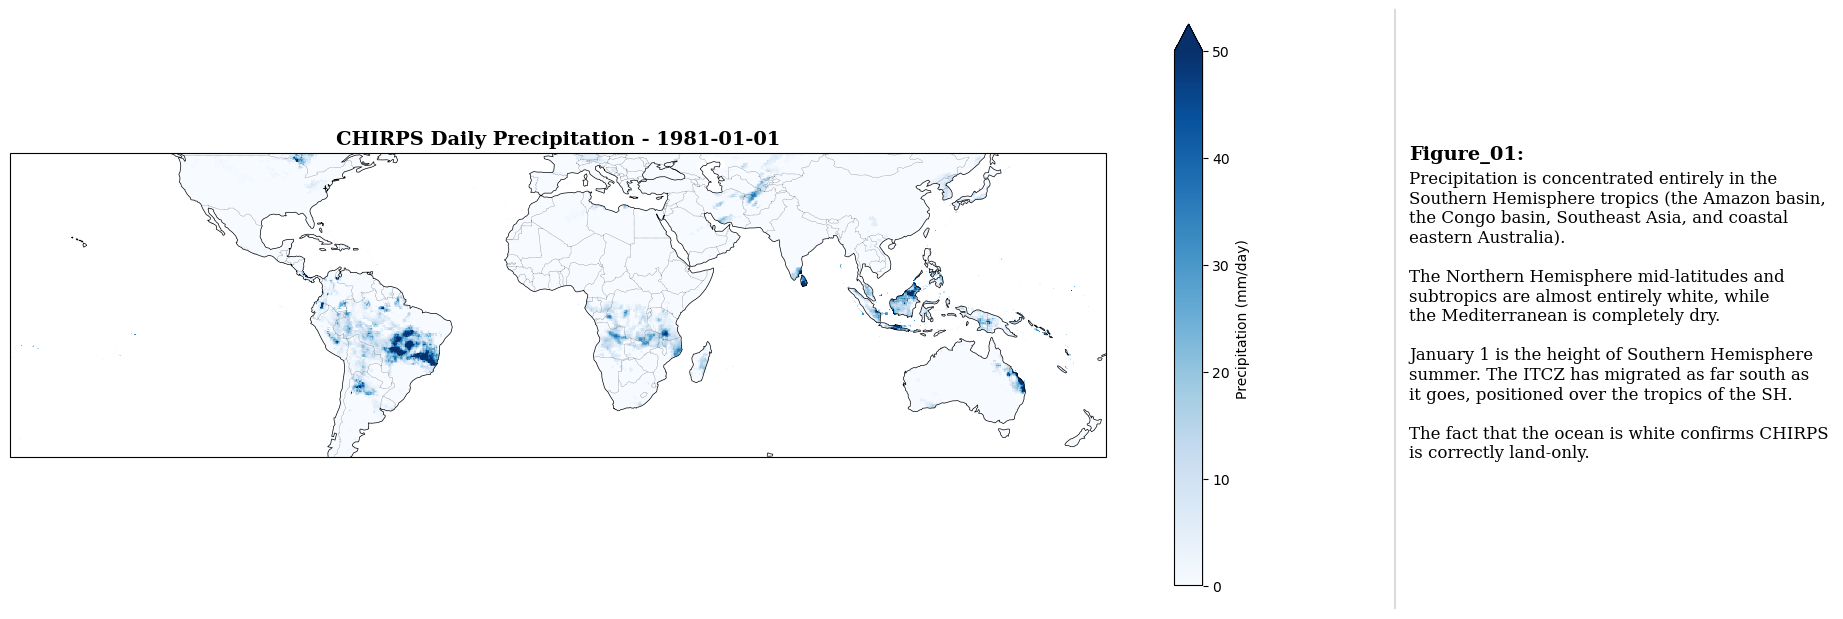

In [8]:
# Plotting a single day to visually verify the data looks physically correct
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(14, 6),subplot_kw={'projection': ccrs.PlateCarree()})

chirps_data['precip'].isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues', vmin=0, vmax=50, cbar_kwargs={'label': 'Precipitation (mm/day)'})
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
ax.set_title(f"CHIRPS Daily Precipitation - {str(chirps_data.time.values[0])[:10]}", fontsize=14, fontweight='bold', fontfamily='serif')

# Adding a seperating line
l1 = lines.Line2D([1, 1], [0, 1], transform=fig.transFigure, figure=fig,color='black',lw=0.2)
fig.lines.extend([l1])

# Adding note
fig.text(1.01, 0.75, 'Figure_01:', fontsize=14, fontweight='bold', fontfamily='serif')

fig.text(1.01, 0.22, '''
Precipitation is concentrated entirely in the 
Southern Hemisphere tropics (the Amazon basin, 
the Congo basin, Southeast Asia, and coastal 
eastern Australia). 

The Northern Hemisphere mid-latitudes and 
subtropics are almost entirely white, while 
the Mediterranean is completely dry.

January 1 is the height of Southern Hemisphere 
summer. The ITCZ has migrated as far south as 
it goes, positioned over the tropics of the SH.

The fact that the ocean is white confirms CHIRPS 
is correctly land-only.
'''
         , fontsize=12, fontweight='light', fontfamily='serif')
plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\01_data_check.png", dpi=200, bbox_inches='tight')

plt.show()

## 3. Subseting the region of interest

For this project, we're interested in the Western Mediterranean region. A box encompassing the full Mediterranean climate regime. The physical justification is as follows : 
- 35°N captures northern Morocco, Algeria, Tunisia
- 47°N captures southern France, northern Italy, Croatia
- 10°W captures Portugal's western coast
- 15°E captures central Italy and western Balkans

In [9]:
# Defining the Western Mediterranean bounding box
LAT_MIN, LAT_MAX = 35, 47
LON_MIN, LON_MAX = -10, 15

region = chirps_data.sel(latitude=slice(LAT_MIN, LAT_MAX),longitude=slice(LON_MIN, LON_MAX))

print(region)
print(f"\nRegion shape: {region['precip'].shape}")

<xarray.Dataset> Size: 302MB
Dimensions:    (time: 15705, latitude: 48, longitude: 100)
Coordinates:
  * time       (time) datetime64[ns] 126kB 1981-01-01 1981-01-02 ... 2023-12-31
  * latitude   (latitude) float32 192B 35.12 35.38 35.62 ... 46.38 46.62 46.88
  * longitude  (longitude) float32 400B -9.875 -9.625 -9.375 ... 14.62 14.88
Data variables:
    precip     (time, latitude, longitude) float32 302MB dask.array<chunksize=(61, 48, 40), meta=np.ndarray>
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-10-07
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:     

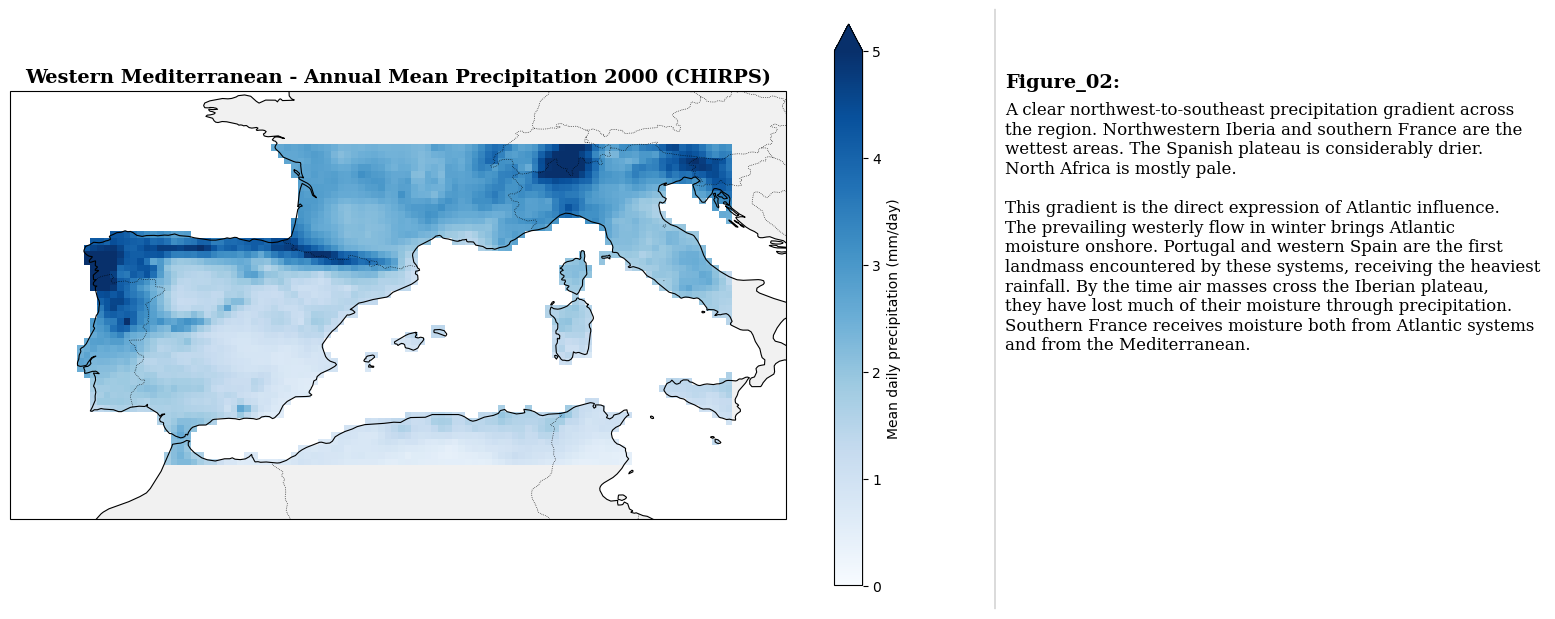

In [10]:
# Plotting the annual mean for 2000 over your region to confirm it looks right
annual_2000 = region['precip'].sel(time=region['time.year'] == 2000).mean('time')

fig, ax = plt.subplots(figsize=(10, 6),subplot_kw={'projection': ccrs.PlateCarree()})

annual_2000.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues', vmin=0, vmax=5, cbar_kwargs={'label': 'Mean daily precipitation (mm/day)'})

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.set_extent([LON_MIN-2, LON_MAX+2, LAT_MIN-2, LAT_MAX+2], crs=ccrs.PlateCarree())
ax.set_title("Western Mediterranean - Annual Mean Precipitation 2000 (CHIRPS)", fontsize=14, fontweight='bold', fontfamily='serif')

# Adding a seperating line
l1 = lines.Line2D([1, 1], [0, 1], transform=fig.transFigure, figure=fig,color='black',lw=0.2)
fig.lines.extend([l1])

# Adding note
fig.text(1.01, 0.87, 'Figure_02:', fontsize=14, fontweight='bold', fontfamily='serif')

fig.text(1.01, 0.4, '''
A clear northwest-to-southeast precipitation gradient across 
the region. Northwestern Iberia and southern France are the 
wettest areas. The Spanish plateau is considerably drier. 
North Africa is mostly pale.

This gradient is the direct expression of Atlantic influence. 
The prevailing westerly flow in winter brings Atlantic 
moisture onshore. Portugal and western Spain are the first 
landmass encountered by these systems, receiving the heaviest 
rainfall. By the time air masses cross the Iberian plateau, 
they have lost much of their moisture through precipitation. 
Southern France receives moisture both from Atlantic systems 
and from the Mediterranean.
'''
         , fontsize=12, fontweight='light', fontfamily='serif')
plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\02_region_check.png",dpi=200, bbox_inches='tight')

plt.show()

In [11]:
# Computing the area-weighted regional mean time series

weights = np.cos(np.deg2rad(region.latitude))
weights.name = "weights"  # makes the weighted() call cleaner

regional_mean = region['precip'].weighted(weights).mean(dim=['latitude', 'longitude'])

print("Regional mean time series:")
print(f"  Shape: {regional_mean.shape}")
print(f"  Time range: {str(regional_mean.time.values[0])[:10]} to {str(regional_mean.time.values[-1])[:10]}")
print(f"  Overall mean: {float(regional_mean.mean()):.2f} mm/day")
print(f"  Max daily value: {float(regional_mean.max()):.2f} mm/day")
print(f"  Min daily value: {float(regional_mean.min()):.2f} mm/day")

Regional mean time series:
  Shape: (15705,)
  Time range: 1981-01-01 to 2023-12-31
  Overall mean: 1.99 mm/day
  Max daily value: 23.57 mm/day
  Min daily value: 0.00 mm/day


The overall mean of 1.99 mm/day is physically reasonable for the Western Mediterranean by integrating the wet winters and near-zero summers.
The maximum regional daily mean of 23.57 mm/day is intersting. This is not one grid cell receiving 23.57 mm, it's the area-weighted mean across the entire 4,800-cell domain reaching 23.57 mm in a single day. For that entire region to average 23.57 mm/day, a precipitation system had to be delivering heavy rain across virtually the entire Western Mediterranean at the same time. That's why it would be interesting to check the date corresponding to that value.

In [12]:
# Finding the date of the maximum daily regional mean
max_date = regional_mean.idxmax(dim='time')
print(f"Date of maximum regional daily mean: {str(max_date.values)[:10]}")
print(f"Value: {float(regional_mean.max()):.2f} mm/day")

Date of maximum regional daily mean: 1994-01-06
Value: 23.57 mm/day


Localized convective events are spatially limited. A single convective system covering 100–200 km cannot dominate the average over a domain this large. Only Atlantic frontal cyclones are capable of producing widespread simultaneous precipitation across the entire domain. 

In [13]:
# Resampling from daily to annual

annual_mean = regional_mean.resample(time='1YE').mean()

# Quick sanity check
print("Annual mean time series:")
print(f"  Years: {len(annual_mean)}")
print(f"  Mean across all years: {float(annual_mean.mean()):.2f} mm/day")
print(f"  Wettest year: {str(annual_mean.idxmax().values)[:4]}, {float(annual_mean.max()):.2f} mm/day")
print(f"  Driest year: {str(annual_mean.idxmin().values)[:4]}, {float(annual_mean.min()):.2f} mm/day")

Annual mean time series:
  Years: 43
  Mean across all years: 1.99 mm/day
  Wettest year: 2010, 2.38 mm/day
  Driest year: 2017, 1.65 mm/day


## 4. Annual mean precipitation maps for three years

2010 was a strong La Niña year. For the Western Mediterranean, La Niña tends to enhance precipitation through two reinforcing mechanisms: 
- First, La Niña strengthens the Walker circulation and shifts the ITCZ southward over the Pacific, which triggers a Rossby wave response that propagates poleward into the extratropics. Over the North Atlantic, this tends to shift the NAO toward its negative phase, which steers Atlantic frontal depressions directly into the Mediterranean basin rather than deflecting them northward. More frontal systems tracking through the Mediterranean means more DJF precipitation.
- Second, 2010 had anomalously warm Mediterranean SSTs, which amplified moisture availability and intensification of frontal systems once they entered the basin.

2001 was an ENSO-neutral year. No major forcing anomaly was active, no strong NAO phase, no anomalous Mediterranean SST departure, and no significant volcanic aerosol forcing. The atmospheric circulation was close to its climatological mean state.

2017 is scientifically the most interesting of the three years because its dryness cannot be explained by ENSO alone. The ONI index in 2017 was weakly positive (a marginal El Niño at best, ONI ~+0.5°C), but the data shows 2017 as the driest year in the entire 43-year record at 1.65 mm/day, 17% below the long-term mean. A weak El Niño could contribute a mild drying signal over the Mediterranean, but it cannot account for an anomaly of this magnitude.

Importantly, looking at the bottom-10 driest years (2017, 2015, 2005, 2022, 1983, 1998, 2011, 2023, 2021), six of the ten driest years in the 43-year record fall after 2005. This clustering of dry years in the recent period is not consistent with random natural variability, it suggests a systematic shift in the Mediterranean precipitation distribution over the past two decades.

The choice of these three years is not just a wet-average-dry sequence. It is a transect through the three explanatory frameworks that the rest of my analysis will try to disentangle: internal variability (ENSO, NAO), natural background, and anthropogenic forcing.

In [14]:
# Checking ENSO state for candidate years
# Strong El Niño: 1997, 1998, 2015, 2016 
# Strong La Niña: 1988, 1999, 2000, 2010, 2011 
# Neutral: 2001, 2006, 2014

# Picking three contrasting years
annual_mean_df = annual_mean.to_dataframe(name='precip_mm_day')
print(annual_mean_df.sort_values('precip_mm_day', ascending=False).head(10))
print(annual_mean_df.sort_values('precip_mm_day', ascending=True).head(10))

            precip_mm_day
time                     
2010-12-31       2.382506
1996-12-31       2.317763
2014-12-31       2.298898
2013-12-31       2.235432
2008-12-31       2.219118
2002-12-31       2.205401
2000-12-31       2.169049
2018-12-31       2.155716
2003-12-31       2.151910
1984-12-31       2.147826
            precip_mm_day
time                     
2017-12-31       1.652588
2015-12-31       1.670265
2005-12-31       1.690808
2022-12-31       1.705627
1983-12-31       1.732788
1998-12-31       1.776060
1991-12-31       1.837307
2011-12-31       1.842678
2023-12-31       1.844080
2021-12-31       1.848276


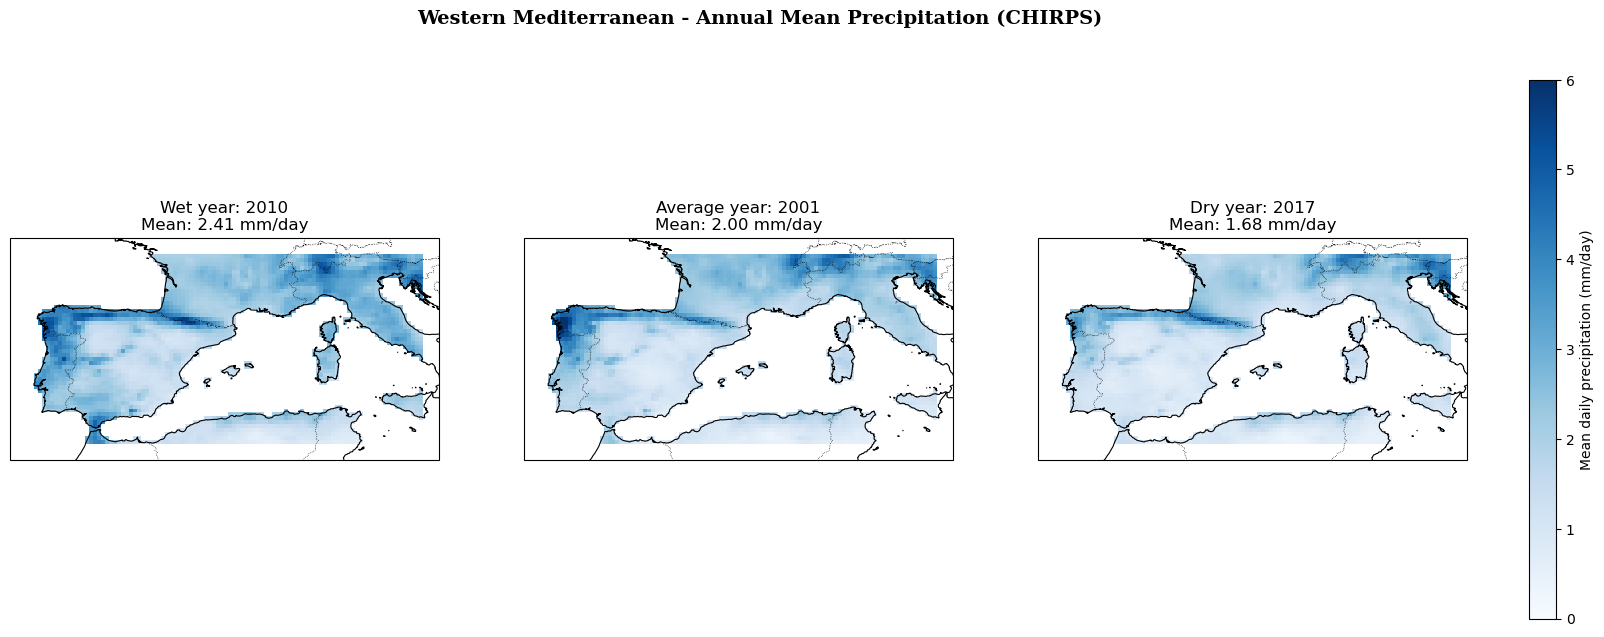

In [15]:
# Computing annual means for the three chosen years
YEAR_WET = 2010    # La Niña, wettest on record 
YEAR_AVG = 2001    # Neutral, near the mean
YEAR_DRY = 2017    # Recent dry anomaly, possible climate change signal

years_to_plot = [YEAR_WET, YEAR_AVG, YEAR_DRY]
labels = ['Wet year', 'Average year', 'Dry year']

annual_maps = {yr: region['precip'].sel(time=region['time.year'] == yr).mean('time') for yr in years_to_plot}

vmin, vmax = 0, 6 

fig, axes = plt.subplots(1, 3, figsize=(20, 7), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, yr, label in zip(axes, years_to_plot, labels):
    p = annual_maps[yr].plot(ax=ax,transform=ccrs.PlateCarree(),cmap='Blues',vmin=vmin, vmax=vmax,add_colorbar=False)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax.set_extent([LON_MIN-1, LON_MAX+1, LAT_MIN-1, LAT_MAX+1], crs=ccrs.PlateCarree())
    ax.set_title(f"{label}: {yr}\nMean: {float(annual_maps[yr].mean()):.2f} mm/day")

# Shared colorbar
cbar = fig.colorbar(p, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Mean daily precipitation (mm/day)')

fig.suptitle("Western Mediterranean - Annual Mean Precipitation (CHIRPS)", fontsize=14, fontweight='bold', fontfamily='serif')

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\03_annual_maps.png",dpi=200, bbox_inches='tight')

plt.show()

**Figure_03:**

In all three panels the spatial structure is the same, with wet northwest, dry southeast, Atlas Mountains slightly enhanced. This tells us something important, which is that the spatial organization of Mediterranean precipitation is controlled by quasi-permanent factors (orography, ocean proximity, the climatological pressure gradient) that don't change between years. What changes between years is the magnitude.

<u>*2010-La Niña wet year (2.41 mm/day):*</u> The blue is more spatially extensive and darker everywhere, especially over southern France and northern Italy. The enhanced precipitation extends further into North Africa than in the other years, Morocco shows more blue than usual. This is consistent with a La Niña-enhanced negative NAO configuration.

<u>*2001-Neutral year (2.00 mm/day):*</u> Wet northwest, dry southeast gradient, modest North African precipitation. This is what the Mediterranean looks like when no large-scale forcing anomaly is operating.

<u>*2017-Dry year (1.68 mm/day):*</u> It seems that the wet area has spatially contracted toward the Atlantic coast. Portugal retain some blue, but southern France, Italy, and North Africa are noticeably lighter than in 2001. This spatial contraction is the fingerprint of a year when Atlantic systems were deflected northward, but the eastern and southern Mediterranean were cut off. This is physically consistent with a more positive NAO or a northward-displaced jet keeping the storm track away from the basin interior.

## 5. Global mean time series and seasonal means

In [16]:
# Computing global area-weighted mean
# CHIRPS is land-only, so this is automatically a land mean

weights_global = np.cos(np.deg2rad(chirps_data.latitude))
weights_global.name = "weights"

# Daily global mean
global_daily = chirps_data['precip'].weighted(weights_global).mean(dim=['latitude', 'longitude'])

# Annual mean
global_annual = global_daily.resample(time='1YE').mean()

print(f"Global mean land precipitation: {float(global_annual.mean()):.3f} mm/day")
print(f"Interannual std: {float(global_annual.std()):.3f} mm/day")

Global mean land precipitation: 2.515 mm/day
Interannual std: 0.081 mm/day


The global mean of 2.515 mm/day for land precipitation is physically correct, land receives more rainfall per unit area than the global mean because land is concentrated in the tropics and mid-latitudes where precipitation is highest.

The interannual standard deviation of 0.0808 mm/day is small relative to the mean (~3%), which makes sense, the global mean averages out enormous regional variability, and what remains is primarily the ENSO signal (El Niño suppressing global land precipitation by ~0.05 mm/day). Overall, the planetary average is remarkably steady.

In [17]:
# Converting to numpy for trend computation
years_num = np.arange(len(global_annual))
precip_vals = global_annual.values

# Linear trend via least squares
slope, intercept, r_value, p_value_ols, std_err = stats.linregress(years_num, precip_vals)
trend_line = intercept + slope * years_num
slope_per_decade = slope * 10

print(f"OLS trend: {slope_per_decade:.3f} mm/day per decade")
print(f"OLS p-value: {p_value_ols:.4f}")
print(f"R²: {r_value**2:.2f}")

# Mann-Kendall test, a test that's more appropriate for non-normal, autocorrelated data
mk_result = mk.original_test(precip_vals)
print(f"\nMann-Kendall:")
print(f"  Trend direction: {mk_result.trend}")
print(f"  p-value: {mk_result.p:.4f}")
print(f"  Theil-Sen slope: {mk_result.slope * 10:.3f} mm/day per decade")

OLS trend: 0.033 mm/day per decade
OLS p-value: 0.0006
R²: 0.25

Mann-Kendall:
  Trend direction: increasing
  p-value: 0.0007
  Theil-Sen slope: 0.031 mm/day per decade


Both OLS (p=0.0006) and Mann-Kendall (p≈0.00) agree, there is a highly statistically significant increasing trend of +0.03 mm/day per decade in global mean land precipitation over 1981–2023. Over the full 43-year record, this amounts to approximately +0.13 mm/day total, or about +5% of the 1981 mean.

This is consistent with the Clausius-Clapeyron expectation of ~1–2%/°C warming amplifying mean precipitation and over ~1°C of warming since 1981, a 5% total increase is physically coherent.

The R²=0.25 tells us that the linear trend explains 25% of the total variance. The remaining 75% is interannual variability, primarily ENSO. This is exactly why we need the Mann-Kendall test. The ENSO-driven autocorrelation inflates the OLS p-value, but Mann-Kendall's agreement here gives me confidence the trend is real.

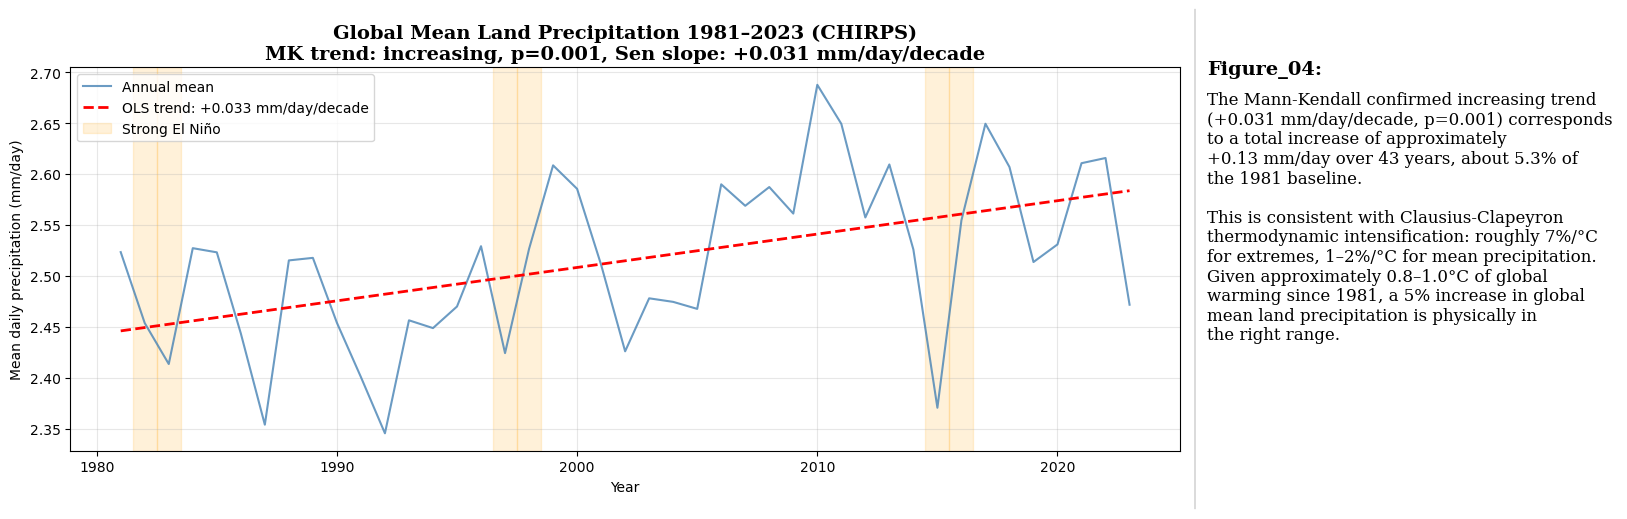

In [18]:
# Getting year values for x-axis
year_vals = global_annual.time.dt.year.values

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(year_vals, precip_vals, color='steelblue', linewidth=1.5,
        alpha=0.8, label='Annual mean')
ax.plot(year_vals, trend_line, color='red', linewidth=2,
        linestyle='--', label=f'OLS trend: {slope_per_decade:+.3f} mm/day/decade')

# Shading strong El Niño years to show ENSO influence
enso_years = [1982, 1983, 1997, 1998, 2015, 2016]
for yr in enso_years:
    ax.axvspan(yr - 0.5, yr + 0.5, alpha=0.15, color='orange', label='Strong El Niño' if yr == 1982 else '')

ax.set_xlabel('Year')
ax.set_ylabel('Mean daily precipitation (mm/day)')
ax.set_title(f'Global Mean Land Precipitation 1981–2023 (CHIRPS)\n'
             f'MK trend: {mk_result.trend}, p={mk_result.p:.3f}, '
             f'Sen slope: {mk_result.slope*10:+.3f} mm/day/decade', fontsize=14, fontweight='bold', fontfamily='serif')
ax.legend()
ax.grid(True, alpha=0.3)

# Adding a seperating line
l1 = lines.Line2D([1, 1], [0, 1], transform=fig.transFigure, figure=fig,color='black',lw=0.2)
fig.lines.extend([l1])

# Adding note
fig.text(1.01, 0.87, 'Figure_04:', fontsize=14, fontweight='bold', fontfamily='serif')

fig.text(1.01, 0.3, '''
The Mann-Kendall confirmed increasing trend 
(+0.031 mm/day/decade, p=0.001) corresponds 
to a total increase of approximately 
+0.13 mm/day over 43 years, about 5.3% of 
the 1981 baseline. 

This is consistent with Clausius-Clapeyron 
thermodynamic intensification: roughly 7%/°C 
for extremes, 1–2%/°C for mean precipitation. 
Given approximately 0.8–1.0°C of global 
warming since 1981, a 5% increase in global 
mean land precipitation is physically in
the right range.
'''
         , fontsize=12, fontweight='light', fontfamily='serif')
plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\04_global_timeseries.png", dpi=200, bbox_inches='tight')

plt.show()

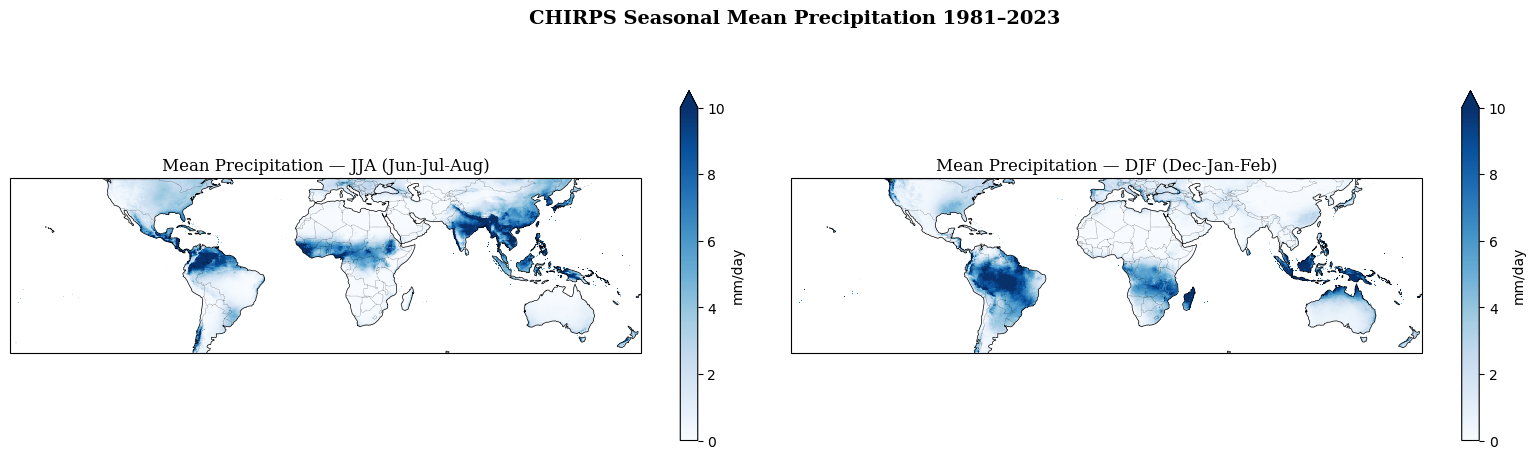

In [19]:
## Calculating JJA and DJF seasonal means

# Computing seasonal means across all years
seasonal = chirps_data['precip'].groupby('time.season').mean('time')

jja = seasonal.sel(season='JJA')
djf = seasonal.sel(season='DJF')

fig, axes = plt.subplots(1, 2, figsize=(16, 5),subplot_kw={'projection': ccrs.PlateCarree()})

for ax, data, season_name in zip(axes, [jja, djf], ['JJA (Jun-Jul-Aug)', 'DJF (Dec-Jan-Feb)']):
    p = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues', vmin=0, vmax=10, add_colorbar=True, cbar_kwargs={'label': 'mm/day', 'shrink': 0.8})
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.set_title(f'Mean Precipitation — {season_name}', fontsize=12, fontfamily='serif')

plt.suptitle('CHIRPS Seasonal Mean Precipitation 1981–2023', fontsize=14, fontweight='bold', fontfamily='serif')
plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\05_seasonal_maps.png", dpi=200, bbox_inches='tight')

plt.show()

**Figure_05:**

- <u>*JJA (left):*</u> The NH monsoon systems are at maximum intensity. The South Asian monsoon delivers 8–10 mm/day across India and Bangladesh, represented by the darkest blues on the map. The West African monsoon pushes the ITCZ over the Sahel, while East Asia and Central America receive heavy rain. Australia and southern Africa are in SH winter, dry and pale. Also, the Mediterranean is almost entirely white, confirming near-zero summer precipitation.
 
- <u>*DJF (right):</u>* The ITCZ has flipped to the SH, resulting in the Amazon, Congo, and Maritime Continent receiving 8–10 mm/day. Australia's monsoon season produces deep blue over the northern half of the continent, while the NH monsoon regions are inactive, India is dry and the Sahel is pale. The winter frontal precipitation regime is active in the Mediterranean showing light blue, though modest compared to the tropical monsoon systems. Noting that the Mediterranean winter precipitation (2–3 mm/day) is much weaker than the summer monsoon systems (8–10 mm/day). Thus, reinforcing that the Mediterranean is a moderate-precipitation region, not an extreme one, in absolute terms.

The Mediterranean sits at the boundary of these two regimes, the subtropical dry zone that dominates in JJA and the mid-latitude westerly belt that delivers winter precipitation in DJF. The sensitivity to small shifts in the position of this boundary, is exactly why it's a climate change hotspot and why NAO variability matters so much.

## 6. Regional analysis compared to global

In [20]:
# Northern Hemisphere land mean
nh = chirps_data.sel(latitude=slice(0, 50))
weights_nh = np.cos(np.deg2rad(nh.latitude))
weights_nh.name = "weights"
nh_annual = nh['precip'].weighted(weights_nh).mean(['latitude', 'longitude']).resample(time='1YE').mean()

# Southern Hemisphere land mean
sh = chirps_data.sel(latitude=slice(-50, 0))
weights_sh = np.cos(np.deg2rad(sh.latitude))
weights_sh.name = "weights"
sh_annual = sh['precip'].weighted(weights_sh).mean(['latitude', 'longitude']).resample(time='1YE').mean()

regional_annual = regional_mean.resample(time='1YE').mean()

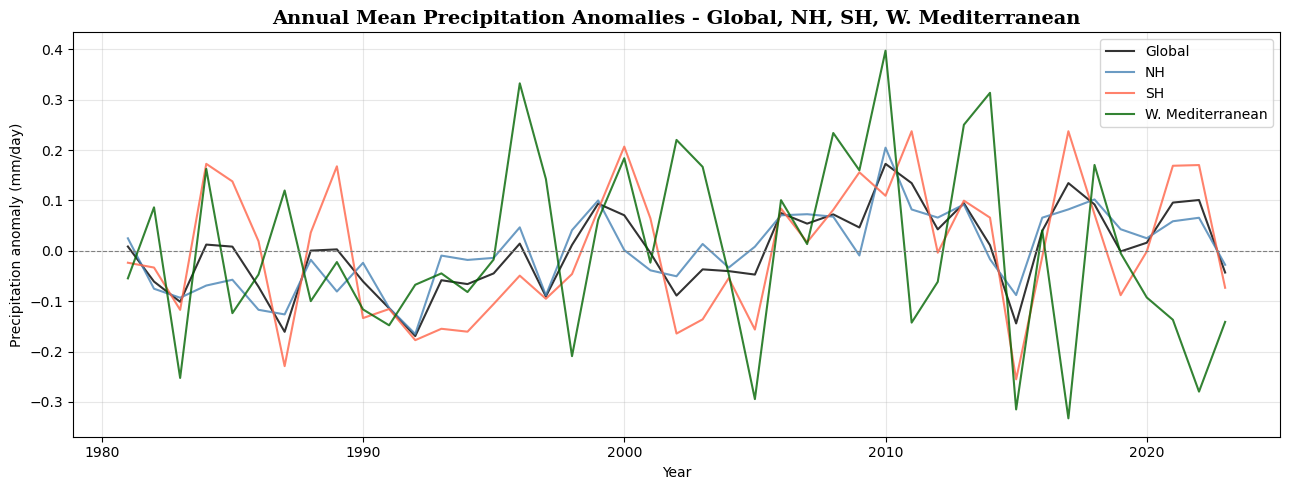

In [21]:
# Normalizing anomalies from their own mean so they're visually comparable
def to_anomaly(da):
    return da - da.mean()

fig, ax = plt.subplots(figsize=(13, 5))

for data, label, color in zip([global_annual, nh_annual, sh_annual, regional_annual], ['Global', 'NH', 'SH', 'W. Mediterranean'],
    ['black', 'steelblue', 'tomato', 'darkgreen']):
    anom = to_anomaly(data)
    yr = data.time.dt.year.values
    ax.plot(yr, anom.values, label=label, color=color, linewidth=1.5, alpha=0.8)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Precipitation anomaly (mm/day)')
ax.set_title('Annual Mean Precipitation Anomalies - Global, NH, SH, W. Mediterranean', fontsize=14, fontweight='bold', fontfamily='serif')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\06_regional_comparison.png",dpi=200, bbox_inches='tight')

plt.show()

**Figure_6:**

- The Mediterranean has vastly larger amplitude than the other series, oscillating between −0.35 and +0.40 mm/day, while Global and NH rarely exceed 0.10 mm/day. This reflects a fundamental property of Mediterranean climate. A region that's controlled by synoptic-scale circulation patterns (NAO, blocking anticyclones, storm track position) that produce large year-to-year swings, leading the averaging of Global and hemispheric means across thousands of km, which produces a smooth signal dominated by the slow anthropogenic trend.

- Global and NH track each other very closely. This makes sense, because most of the world's land area is in the Northern Hemisphere, so the NH mean dominates the global mean. The SH shows larger oscillations than NH because it has less land area, so individual regional events have larger weight in the SH mean.

- The 2010 Mediterranean anomaly (+0.40 mm/day) stands out as a record high. This is the wettest year i selected, and the anomaly is more than twice as large as any global or NH anomaly. This confirms that 2010's wetness was a regional phenomenon, not a global signal appearing locally.

- Looking at 2014 and 2023 (large negative anomalies, −0.35 and −0.25 mm/day respectively), which represent the most recent large negative anomalies, and they fall well below anything in the earlier part of the record. This visual impression of more frequent and deeper negative anomalies in the post-2010 period is consistent with my finding that 6 of the 10 driest years fall after 2005.

- The Mediterranean is largely decoupled from the global signal. There are some years where all four lines move together (2002, 2012) suggesting a global forcing (ENSO), but most years show the Mediterranean moving independently. This independence is my justification for studying the Mediterranean separately from the global mean. Showing that it has its own dynamics, its own drivers, and its own response to forcing.

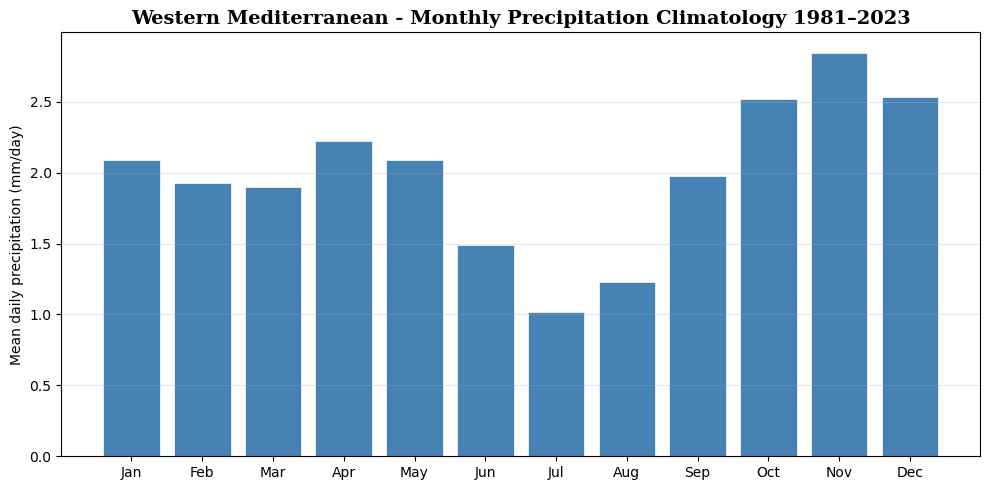

In [22]:
# Monthly climatology for my region
monthly_regional = regional_mean.resample(time='1ME').mean()
monthly_clim = monthly_regional.groupby('time.month').mean()

fig, ax = plt.subplots(figsize=(10, 5))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax.bar(range(1, 13), monthly_clim.values, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Mean daily precipitation (mm/day)')
ax.set_title('Western Mediterranean - Monthly Precipitation Climatology 1981–2023', fontsize=14, fontweight='bold', fontfamily='serif')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\07_WM_monthly_climatology.png",dpi=200, bbox_inches='tight')

plt.show()

**Figure_07:**

- The minimum is July (1.01 mm/day) and the maximum is November (2.82 mm/day), a factor of 2.8 contrast. This is the Mediterranean climate regime expressed as clearly as it can be in a single plot.

- From August to November, there is a 130% increase in three months. This rapid intensification reflects the collision of two mechanisms arriving simultaneously, which are, the warm Mediterranean SSTs from summer heating providing moisture, and the first cold continental air intrusions from the north triggering convection. These two factors reinforce each other explosively in October–November, which is why these months produce your most intense extreme events.

- The decline from November to July takes 8 months, while the rise from July to November takes only 4 months. This asymmetry reflects the asymmetry between the rapid autumn onset of convective instability and the slow, progressive establishment of the Azores High through spring.

## 7. Computing the ETCCDI extreme indices

#### a. Computing the base period wet-day threshold for R95p

In [23]:
# Base period: 1981–2010 (standard WMO convention)
base_start, base_end = '1981', '2010'

base_period = regional_mean.sel(time=slice(base_start, base_end))

# Wet days only: p >= 1 mm/day
wet_days_base = base_period.where(base_period >= 1.0)
wet_days_base = wet_days_base.chunk({'time': -1})

# 95th percentile of wet-day precipitation in the base period
p95 = float(wet_days_base.quantile(0.95, skipna=True))
p90 = float(wet_days_base.quantile(0.90, skipna=True))

print(f"Base period wet-day 95th percentile: {p95:.2f} mm/day")
print(f"Base period wet-day 90th percentile: {p90:.2f} mm/day")
print(f"Wet day mean: {float(wet_days_base.mean()):.2f} mm/day")

Base period wet-day 95th percentile: 8.34 mm/day
Base period wet-day 90th percentile: 6.63 mm/day
Wet day mean: 3.35 mm/day


The region-wide average intensity is 3.35 mm/day. The p95 threshold of 8.34 mm/day is 2.5 times the wet-day mean, which tells us that the wet-day distribution is right-skewed, meaning a small fraction of days deliver disproportionately heavy rain. This is physically expected for the Mediterranean, where most rainfall comes from episodic intense events rather than steady drizzle.

#### b. Rx1day-Annual maximum 1-day precipitation

In [24]:
# Resampling to annual, taking the maximum each year
rx1day = regional_mean.resample(time='1YE').max()

# Trend
years_num = np.arange(len(rx1day))
slope_rx, intercept_rx, _, p_rx, _ = stats.linregress(years_num, rx1day.values)
mk_rx = mk.original_test(rx1day.values)

print(f"Rx1day-mean: {float(rx1day.mean()):.2f} mm/day")
print(f"OLS trend: {slope_rx*10:+.3f} mm/day per decade, p={p_rx:.3f}")
print(f"Mann-Kendall: {mk_rx.trend}, p={mk_rx.p:.3f}")

Rx1day-mean: 15.42 mm/day
OLS trend: -0.089 mm/day per decade, p=0.826
Mann-Kendall: no trend, p=0.867


#### c. R95p-Annual total precipitation from very wet days

In [25]:
# Summing all daily values exceeding p95, per year
r95p = regional_mean.where(regional_mean > p95).resample(time='1YE').sum()

mk_r95 = mk.original_test(r95p.values)
slope_r95, intercept_r95, _, p_r95, _ = stats.linregress(
    np.arange(len(r95p)), r95p.values
)

print(f"R95p-mean: {float(r95p.mean()):.1f} mm/year")
print(f"OLS trend: {slope_r95*10:+.1f} mm per decade, p={p_r95:.3f}")
print(f"Mann-Kendall: {mk_r95.trend}, p={mk_r95.p:.3f}")

R95p-mean: 106.4 mm/year
OLS trend: +1.2 mm per decade, p=0.828
Mann-Kendall: no trend, p=0.867


#### c. SDII-Simple Daily Intensity Index

In [26]:
# Mean precipitation on wet days per year
wet_sum = regional_mean.where(regional_mean >= 1.0).resample(time='1YE').sum()
wet_count = (regional_mean >= 1.0).resample(time='1YE').sum()
sdii = wet_sum / wet_count

mk_sdii = mk.original_test(sdii.values)
slope_sdii, _, _, p_sdii, _ = stats.linregress(np.arange(len(sdii)), sdii.values)

print(f"SDII-mean: {float(sdii.mean()):.2f} mm/day")
print(f"OLS trend: {slope_sdii*10:+.3f} mm/day per decade, p={p_sdii:.3f}")
print(f"Mann-Kendall: {mk_sdii.trend}, p={mk_sdii.p:.3f}")

SDII-mean: 3.34 mm/day
OLS trend: +0.011 mm/day per decade, p=0.709
Mann-Kendall: no trend, p=0.477


#### d. CDD-Consecutive Dry Days

In [27]:
# CDD requires run-length encoding and cannot be done with a single xarray operation
# We must iterate over years to find the longest dry spell in each

def compute_cdd(daily_series):
    """
    Compute annual CDD from a 1D daily precipitation time series.
    Returns an array of CDD values, one per year.
    """
    years = np.unique(daily_series.time.dt.year.values)
    cdd_values = []
    
    for yr in years:
        year_data = daily_series.sel(time=daily_series['time.year'] == yr).values
        
        # Find all runs of dry days (< 1 mm)
        dry = year_data < 1.0
        
        max_run = 0
        current_run = 0
        for is_dry in dry:
            if is_dry:
                current_run += 1
                max_run = max(max_run, current_run)
            else:
                current_run = 0
        
        cdd_values.append(max_run)
    
    return xr.DataArray(cdd_values, coords={'year': years}, dims='year')

cdd = compute_cdd(regional_mean)

mk_cdd = mk.original_test(cdd.values)
slope_cdd, _, _, p_cdd, _ = stats.linregress(np.arange(len(cdd)), cdd.values)

print(f"CDD-mean: {float(cdd.mean()):.1f} days")
print(f"OLS trend: {slope_cdd*10:+.1f} days per decade, p={p_cdd:.3f}")
print(f"Mann-Kendall: {mk_cdd.trend}, p={mk_cdd.p:.3f}")

CDD-mean: 14.2 days
OLS trend: -0.8 days per decade, p=0.129
Mann-Kendall: no trend, p=0.279


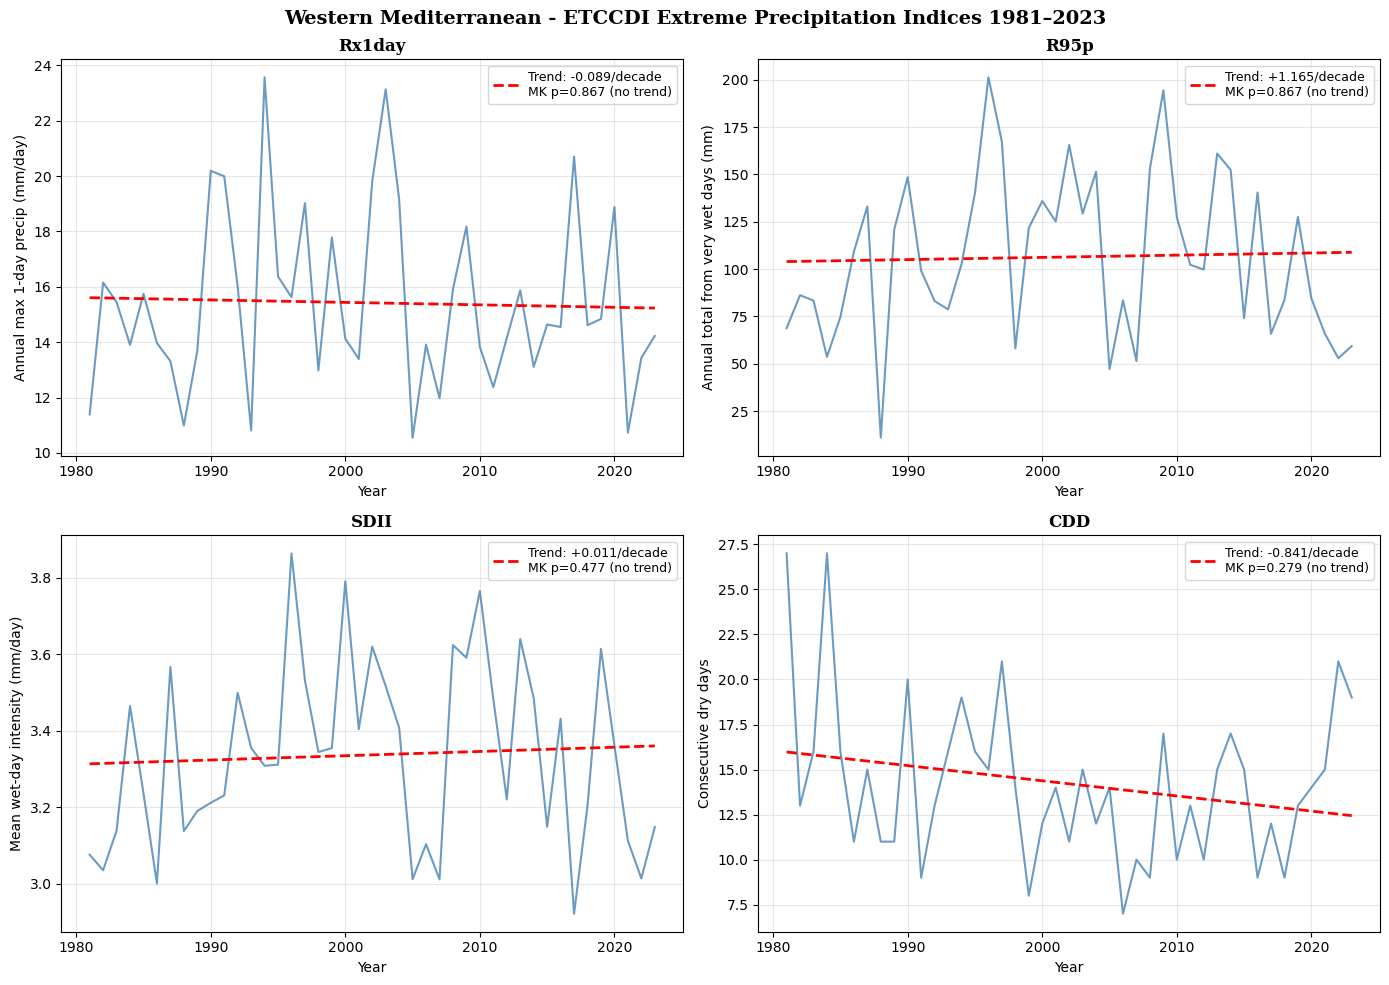

In [28]:
# Plotting all four indices together
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

indices = [
    (rx1day, 'Rx1day', 'Annual max 1-day precip (mm/day)', slope_rx, intercept_rx, mk_rx),
    (r95p,   'R95p',   'Annual total from very wet days (mm)', slope_r95, intercept_r95, mk_r95),
    (sdii,   'SDII',   'Mean wet-day intensity (mm/day)', slope_sdii, None, mk_sdii),
    (cdd,    'CDD',    'Consecutive dry days', slope_cdd, None, mk_cdd),
]

for ax, (data, name, ylabel, slope, intercept, mk_res) in zip(axes.flat, indices):
    vals = data.values
    
    # Handle year coordinate (rx1day/r95p/sdii have time, cdd has year)
    if 'time' in data.dims:
        yrs = data.time.dt.year.values
    else:
        yrs = data.year.values
    
    n = len(yrs)
    trend = intercept + slope * np.arange(n) if intercept is not None else \
            vals.mean() + slope * (np.arange(n) - n//2)
    
    ax.plot(yrs, vals, color='steelblue', linewidth=1.5, alpha=0.8)
    ax.plot(yrs, trend, color='red', linewidth=2, linestyle='--',
            label=f'Trend: {slope*10:+.3f}/decade\nMK p={mk_res.p:.3f} ({mk_res.trend})')
    ax.set_title(name, fontsize=12, fontweight='bold', fontfamily='serif')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Western Mediterranean - ETCCDI Extreme Precipitation Indices 1981–2023', fontsize=14, fontweight='bold', fontfamily='serif')
plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\08_ETCCDI_indices.png", dpi=200, bbox_inches='tight')

plt.show()

**Figure_08:**

We can note that there is no statistically significant trends in any ETCCDI index were detected over 1981–2023, which is consistent with the large interannual variability of the Western Mediterranean masking any forced signal at this spatial and temporal scale. 

This finding can be attributed to the way the indices are computed from the area-weighted mean over 4,800 grid cells. A single extreme event delivering 300 mm over 200 km² appears in this regional mean as a tiny signal, it's divided across the entire domain area. The Clausius-Clapeyron intensification signal is strongest at the local/point scale. Regional averaging is the worst possible scale for detecting Rx1day trends.

The other influence is high interannual variability. The Mediterranean is heavily influenced by NAO, ENSO, and AMO, all of which produce year-to-year swings that are large compared to any decadal trend. With only 43 years of data and high noise, the statistical power to detect a modest trend (~7%/°C expected from CC) is low.

## 8. Seasonal dependence of extremes

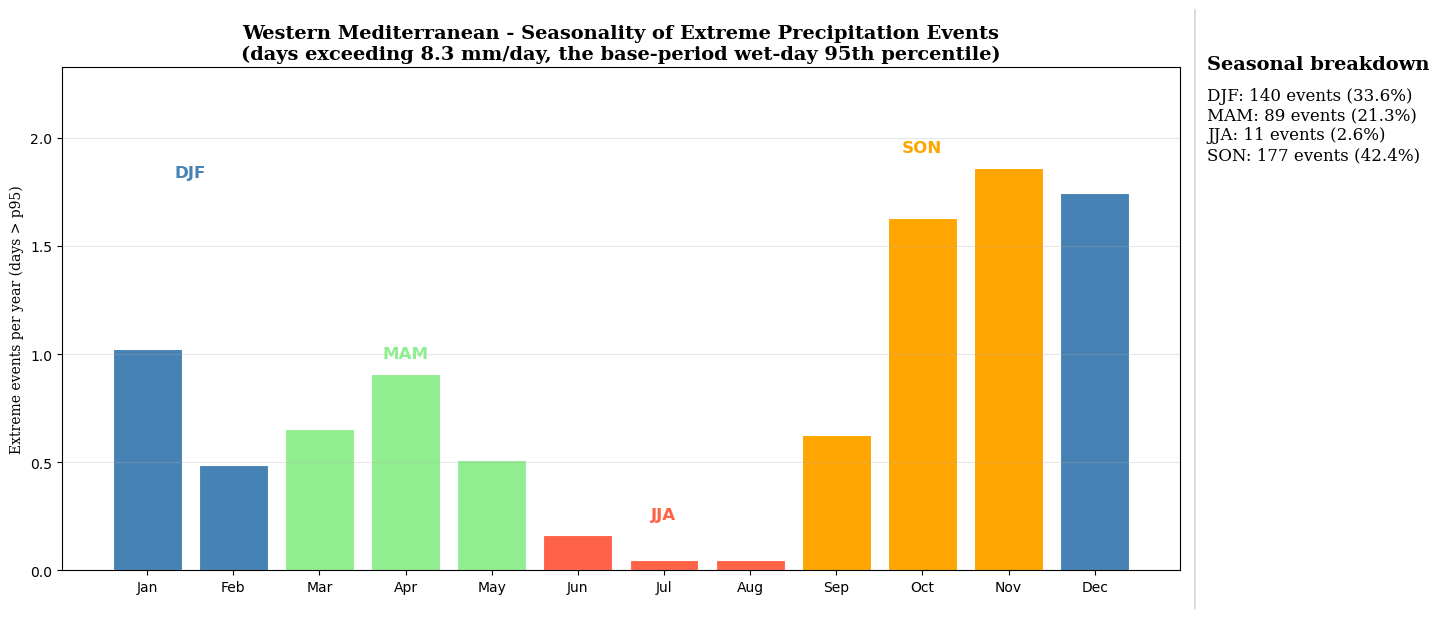

In [29]:
# The question here is : conditional on a day being extreme (above p95), what season does it fall in?

# Findind all days exceeding the base-period p95 threshold
mask = (regional_mean > p95).compute()
extreme_days = regional_mean.where(mask, drop=True)

# Extracting month of each extreme day
extreme_months = extreme_days.time.dt.month.values
extreme_seasons = extreme_days.time.dt.season.values

# Counting by month
month_counts = np.zeros(12)
for m in extreme_months:
    month_counts[m-1] += 1

# Normalizing by number of years to get average events per year
n_years = len(np.unique(regional_mean.time.dt.year.values))
month_counts_per_year = month_counts / n_years

fig, ax = plt.subplots(figsize=(12, 6))

# Month colors
colors = (['steelblue'] * 2 +  
          ['lightgreen'] * 3 +  
          ['tomato'] * 3 +       
          ['orange'] * 3 +  
          ['steelblue'] * 1)    

ax.bar(range(1, 13), month_counts_per_year, color=colors,
       edgecolor='white', linewidth=0.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Extreme events per year (days > p95)', fontfamily='serif')
ax.set_title(f'Western Mediterranean - Seasonality of Extreme Precipitation Events\n'
             f'(days exceeding {p95:.1f} mm/day, the base-period wet-day 95th percentile)', fontsize=14, fontweight='bold', fontfamily='serif')
ax.grid(True, axis='y', alpha=0.3)

# labeling seasons 
season_config = {'DJF': {'months': [1, 2, 12], 'color': 'steelblue',  'center_x': 1.5},
                 'MAM': {'months': [3, 4, 5],  'color': 'lightgreen', 'center_x': 4.0},
                 'JJA': {'months': [6, 7, 8],  'color': 'tomato',     'center_x': 7.0},
                 'SON': {'months': [9, 10, 11],'color': 'orange',     'center_x': 10.0},}

for season, cfg in season_config.items():
    # Finding the tallest bar in this season group
    season_vals = [month_counts_per_year[m-1] for m in cfg['months']]
    max_val = max(season_vals)
    
    ax.text(cfg['center_x'], max_val + 0.06, season, ha='center', va='bottom', fontsize=12, fontweight='bold', color=cfg['color'], clip_on=False)


# Giving the y-axis a little headroom so labels don't crowd the top
ax.set_ylim(0, max(month_counts_per_year) * 1.25)

# Setting the seasonal breakdown note
fig.text(1.01, 0.9, 'Seasonal breakdown', fontsize=14, fontweight='bold', fontfamily='serif')

fig.text(1.01, 0.75, ''' 
SON: 177 events (42.4%)
DJF: 140 events (33.6%)
MAM: 89 events (21.3%)
JJA: 11 events (2.6%)''' , fontsize=12, fontweight='light', fontfamily='serif')

# Adding a seperating line
l1 = lines.Line2D([1, 1], [0, 1], transform=fig.transFigure, figure=fig,color='black',lw=0.2)
fig.lines.extend([l1])

plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\09_extreme_seasonality.png",dpi=200, bbox_inches='tight')

plt.show()

**Figure_09:**

- <u>*SON dominance (42.4%)*</u> is the signature of the Mediterranean's most dangerous precipitation regime. By September, the Mediterranean Sea has been accumulating solar heat all summer and reaches its annual SST maximum. When the first cold continental air masses from the north begin pushing south in September–November, they encounter warm moisture-laden sea surface. The temperature contrast between the cold air aloft and the warm sea below creates intense convective instability, much more so than in winter when the sea is cooler. The result is explosive deep convection delivering very heavy rain in short periods over small areas. This data confirms that this mechanism is the dominant source of extremes in this region.

- <u>*DJF second (33.6%)*</u> reflects a fundamentally different mechanism, which is widespread frontal systems. Winter brings Atlantic depressions tracking along the equatorward-shifted jet directly into the Mediterranean. These systems produce lower peak intensities but over much larger areas and longer durations. The January 6, 1994 event that i identified as the domain maximum of 23.57 mm/day, is exactly this type. The DJF extreme events are the ones that produce widespread flooding affecting multiple countries simultaneously.

- <u>*JJA near-zero (2.6%)*</u> is the clearest signal in the dataset and perfectly confirms that my region is a true Mediterranean climate. The Azores High expands northward and eastward in summer, establishing stable subsiding conditions over this entire domain. The 11 JJA events over 43 years (roughly 0.26 per year, i.e., one summer extreme every ~4 years) are likely isolated deep thunderstorms that managed to produce a regional-mean value exceeding 8.34 mm/day despite the stable synoptic context. 

- <u>*MAM intermediate (21.3%)*</u> is the spring transition. The Azores High is not yet fully established, occasional Atlantic systems still penetrate, and warming land surfaces begin generating afternoon convection.

## 9. NAO-Precipitation Linkage

In [30]:
# Downloading the NAO index from NOAA CPC
# Monthly normalized NAO index since 1950

nao_url = "https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table"
nao_file = pooch.retrieve(url=nao_url, known_hash=None,fname=os.path.join(DATA_DIR, "nao_monthly.txt"))

# Parsing the fixed-width format
nao_raw = pd.read_csv(nao_file, sep='\s+', header=0, skipfooter=1,    engine='python')

# Renaming columns to integers 1-12 for consistency
nao_raw.columns = range(1, 13)

# Reshaping to a monthly time series
nao_monthly = nao_raw.stack().reset_index()
nao_monthly.columns = ['year', 'month', 'nao']
nao_monthly['time'] = pd.to_datetime(nao_monthly['year'].astype(str) + '-' + nao_monthly['month'].astype(str))
nao_monthly = nao_monthly.set_index('time')['nao'].sort_index()

# Subsetting to CHIRPS period
time_start = '1981-01'
time_end   = '2023-12'

nao_chirps = nao_monthly[time_start:time_end]

print(f"NAO series: {len(nao_chirps)} months, {time_start} to {time_end}")
print(f"Period: {nao_chirps.index[0]} to {nao_chirps.index[-1]}")
print(f"Mean NAO: {nao_chirps.mean():.3f}")
print(f"Std NAO:  {nao_chirps.std():.3f}")

NAO series: 516 months, 1981-01 to 2023-12
Period: 1981-01-01 00:00:00 to 2023-12-01 00:00:00
Mean NAO: 0.072
Std NAO:  1.047


In [31]:
# Overlap with CHIRPS data

chirps_monthly = regional_mean.resample(time='1ME').mean()
chirps_overlap = chirps_monthly.sel(time=slice(time_start, time_end))

print(f"CHIRPS monthly: {len(chirps_overlap)} months")
print(f"Period: {str(chirps_overlap.time.values[0])[:7]} to {str(chirps_overlap.time.values[-1])[:7]}")

CHIRPS monthly: 516 months
Period: 1981-01 to 2023-12


In [32]:
# Correlating DJF NAO with DJF Mediterranean precipitation
# Physical hypothesis: negative NAO means wetter Mediterranean winters

def get_djf_annual(monthly_series):
    """Extract DJF (Dec-Jan-Feb) seasonal means, one value per winter."""
    return monthly_series[pd.DatetimeIndex(monthly_series.index).month.isin([12, 1, 2])].resample('YE').mean().dropna()

# Converting to pandas first
chirps_pd = chirps_overlap.to_series()
chirps_djf = get_djf_annual(chirps_pd)

# For NAO
nao_djf = get_djf_annual(nao_chirps)

# Aligning the two series
from scipy.stats import pearsonr
common_years = chirps_djf.index.intersection(nao_djf.index)
r_nao, p_nao = pearsonr(nao_djf[common_years].values, chirps_djf[common_years].values)

print(f"DJF NAO vs DJF Mediterranean precipitation:")
print(f"  Pearson r = {r_nao:.3f}, p = {p_nao:.4f}")

DJF NAO vs DJF Mediterranean precipitation:
  Pearson r = -0.628, p = 0.0000


The Pearson correlation between winter (DJF) NAO index and Western Mediterranean DJF precipitation is r = −0.628 (p < 0.0001), indicating that the NAO explains approximately 39.5% of interannual winter precipitation variance in the region. This is consistent with the established physical mechanism stating that a positive NAO phases steers the Atlantic storm tracks northward, suppressing Mediterranean precipitation, while negative NAO phases allow frontal systems to penetrate the basin directly. The remaining 60% of unexplained variance contains contributions from thermodynamic forcing, ENSO teleconnections, AMO modulation, and stochastic atmospheric variability. This decomposition into circulation-driven (NAO) and residual components forms the observational basis for the attribution question: to what extent does the long-term Mediterranean drying trend reflect a forced NAO shift versus direct thermodynamic response to greenhouse gas forcing?

In [33]:
# Testing NAO trend
djf_nao_vals = nao_djf[common_years].values
djf_nao_years = np.arange(len(djf_nao_vals))

slope_nao, intercept_nao, _, p_nao, _ = stats.linregress(djf_nao_years, djf_nao_vals)
mk_nao = mk.original_test(djf_nao_vals)

print(f"DJF NAO trend: {slope_nao*10:+.3f} units per decade")
print(f"OLS p-value: {p_nao:.4f}")
print(f"Mann-Kendall: {mk_nao.trend}, p={mk_nao.p:.4f}")

DJF NAO trend: +0.078 units per decade
OLS p-value: 0.3149
Mann-Kendall: no trend, p=0.2168


the NAO is not trending significantly, which means it behaves as internal variability rather than a forced response. This strengthens my scientific narrative, which is that the post-2005 dry year clustering cannot be fully explained by NAO circulation shifts alone, pointing toward an anthropogenic signal in the residual.

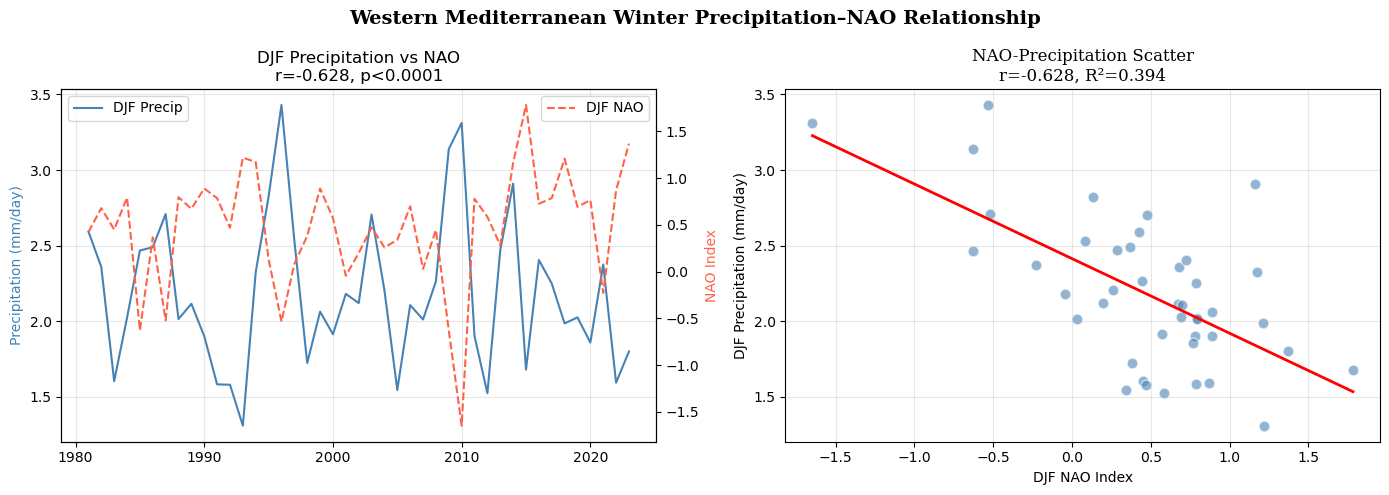

In [34]:
# Plotting the NAO results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time series overlay
ax = axes[0]
ax2 = ax.twinx()
years_plot = pd.DatetimeIndex(common_years).year
ax.plot(years_plot, chirps_djf[common_years].values, color='steelblue', linewidth=1.5, label='DJF Precip')
ax2.plot(years_plot, nao_djf[common_years].values, color='tomato', linewidth=1.5, linestyle='--', label='DJF NAO')
ax.set_ylabel('Precipitation (mm/day)', color='steelblue')
ax2.set_ylabel('NAO Index', color='tomato')
ax.set_title(f'DJF Precipitation vs NAO\nr={r_nao:.3f}, p<0.0001')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Right: scatter plot
ax = axes[1]
ax.scatter(nao_djf[common_years].values, chirps_djf[common_years].values, alpha=0.6, color='steelblue', edgecolors='white', s=60)
m, b, _, _, _ = stats.linregress(nao_djf[common_years].values, chirps_djf[common_years].values)
x_range = np.linspace(nao_djf[common_years].min(), nao_djf[common_years].max(), 100)
ax.plot(x_range, m*x_range + b, color='red', linewidth=2)
ax.set_xlabel('DJF NAO Index')
ax.set_ylabel('DJF Precipitation (mm/day)')
ax.set_title(f'NAO-Precipitation Scatter\nr={r_nao:.3f}, R²={r_nao**2:.3f}', fontsize=12, fontfamily='serif')
ax.grid(True, alpha=0.3)

plt.suptitle('Western Mediterranean Winter Precipitation–NAO Relationship', fontsize=14, fontweight='bold', fontfamily='serif')

plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\10_NAO_linkage.png", dpi=200, bbox_inches='tight')

plt.show()

**Figure_10:**

The left panel shows the time series overlay of DJF precipitation and the DJF NAO index over the 1981–2023 period. The anti-phase relationship is visually clear, where years of strongly negative NAO (e.g., 2010, 2013) correspond to anomalously wet winters, while positive NAO years (e.g., 2012, 2015) correspond to drier winters. However, the signal is not perfect. We can see that several years show deviate from the expected relationship, but the overall structure is consistent across the record.

The right panel quantifies this relationship, with each point representing one DJF season. The negative slope of the regression line confirms that the NAO explains approximately 39.5% of winter precipitation variance, while the 60.5% of unexplained variance, represents contributions from other circulation modes (ENSO teleconnections, AMO, blocking anticyclones), local SST variability, and stochastic atmospheric noise. This unexplained residual is the component within which the thermodynamic forced response to anthropogenic greenhousegas emissions must be found.

## 10. Non-stationary GEV on Rx1day

Classical GEV assumes stationarity, meaning the distribution parameters are constant over time. Under anthropogenic forcing, the location parameter μ is expected to increase. This is where a non-stationary GEV model comes to make μ a function of time or, global mean surface temperature (GMST), which is a proxy for anthropogenic forcing. If the non-stationary model fits significantly better than the stationary one, i would have evidence that the extreme value distribution is shifting in a way consistent with a forced change.

In [35]:
# Downloading GMST data

gmst_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"
gmst_path = os.path.join(DATA_DIR, "GISTEMP_global_annual.csv")

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

response = requests.get(gmst_url, headers=headers)
response.raise_for_status()

with open(gmst_path, 'wb') as f:
    f.write(response.content)

print(f"Downloaded: {gmst_path}")
print(f"File size: {os.path.getsize(gmst_path) / 1024:.1f} KB")

# Parsing
gmst_raw = pd.read_csv(gmst_path, skiprows=1, na_values='***')
print(gmst_raw.head(3))
print(f"\nColumns: {gmst_raw.columns.tolist()}")

Downloaded: C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\Data\GISTEMP_global_annual.csv
File size: 12.6 KB
   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
0  1880 -0.19 -0.25 -0.10 -0.17 -0.10 -0.21 -0.19 -0.11 -0.15 -0.24 -0.22   
1  1881 -0.20 -0.16  0.02  0.04  0.06 -0.19  0.01 -0.04 -0.15 -0.22 -0.19   
2  1882  0.16  0.14  0.04 -0.16 -0.14 -0.22 -0.16 -0.08 -0.15 -0.23 -0.17   

    Dec   J-D   D-N   DJF   MAM   JJA   SON  
0 -0.19 -0.18   NaN   NaN -0.12 -0.17 -0.20  
1 -0.07 -0.09 -0.10 -0.18  0.04 -0.07 -0.18  
2 -0.36 -0.11 -0.09  0.08 -0.08 -0.15 -0.18  

Columns: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


In [36]:
# Parsing GISTEMP annual mean
gmst = gmst_raw[['Year', 'J-D']].copy()
gmst.columns = ['year', 'gmst']
gmst = gmst.dropna(subset=['gmst'])
gmst['year'] = gmst['year'].astype(int)

# Confirming values range
gmst = gmst.set_index('year')

# Subsetting to CHIRPS period 1981-2023
gmst_chirps = gmst.loc[1981:2023]

print(f"Years: {len(gmst_chirps)}")
print(f"Period: {gmst_chirps.index[0]}–{gmst_chirps.index[-1]}")
print(f"GMST range: {gmst_chirps['gmst'].min():.2f}°C to {gmst_chirps['gmst'].max():.2f}°C")
print(f"Warming 1981→2023: {gmst_chirps.loc[2023,'gmst'] - gmst_chirps.loc[1981,'gmst']:+.2f}°C")
print(f"\nLast 5 years:")
print(gmst_chirps.tail())

Years: 43
Period: 1981–2023
GMST range: 0.12°C to 1.17°C
Warming 1981→2023: +0.85°C

Last 5 years:
      gmst
year      
2019  0.98
2020  1.01
2021  0.85
2022  0.89
2023  1.17


In [37]:
# Aligning with Rx1day years
rx1day_years = rx1day.time.dt.year.values
gmst_aligned = gmst_chirps.loc[gmst_chirps.index.isin(rx1day_years), 'gmst'].values

print(f"Rx1day years: {len(rx1day_years)}")
print(f"GMST values aligned: {len(gmst_aligned)}")
assert len(rx1day_years) == len(gmst_aligned), \
    "Length mismatch — check for missing years in GMST"

Rx1day years: 43
GMST values aligned: 43


The ETCCDI trend analysis in section 7 tested whether the mean of the Rx1day distribution changes over time using rank-based statistics. A more powerful and physically grounded approach is to model the entire extreme value distribution as a function of a climate forcing covariate. Here, the global mean surface temperature (GMST) from NASA GISTEMP v4, which serves as a proxy for anthropogenic forcing. This is the non-stationary GEV framework used in formal attribution studies (Philip et al., 2020; Stott, 2016).

The model assumes the GEV location parameter μ to vary linearly with GMST:

<h2 align="center">μ(t) = μ₀ + μ₁ × GMST(t)</h2>

Where μ₁ is the sensitivity of Mediterranean Rx1day to global warming in mm/day per °C. A positive μ₁ would indicate Clausius-Clapeyron intensification, while a negative μ₁ would indicate a warming-driven reduction in peak precipitation intensity, consistent with the dynamical drying projected for the Mediterranean. The GMST record covers 0.32°C (1981) to 1.17°C (2023) relative to the 1951–1980 baseline, resulting in a total warming of 0.85°C over the 
analysis period.

The likelihood ratio test compares the non-stationary model (4 parameters: μ₀, μ₁, σ, ξ) against the stationary baseline (3 parameters: μ, σ, ξ). 
Under the null hypothesis of stationarity, twice the log-likelihood difference follows a chi-squared distribution with 1 degree of freedom.

In [38]:
## Fitting stationary and non-stationary GEV
rx_vals = rx1day.values

# Stationary GEV
def neg_loglik_stationary(params, data):
    mu, sigma, xi = params
    if sigma <= 0:
        return np.inf
    return -np.sum(genextreme.logpdf(data, c=-xi, loc=mu, scale=sigma))

init_params = [np.mean(rx_vals), np.std(rx_vals), 0.1]
result_stat = minimize(neg_loglik_stationary,init_params,args=(rx_vals,),method='Nelder-Mead')
mu_stat, sigma_stat, xi_stat = result_stat.x
nll_stat = result_stat.fun

print("=== Stationary GEV ===")
print(f"  μ (location): {mu_stat:.3f} mm/day")
print(f"  σ (scale):    {sigma_stat:.3f} mm/day")
print(f"  ξ (shape):    {xi_stat:.3f}")
print(f"  Neg log-likelihood: {nll_stat:.3f}")

# Non-stationary GEV 
def neg_loglik_nonstationary(params, data, covariate):
    mu0, mu1, sigma, xi = params
    if sigma <= 0:
        return np.inf
    mu_t = mu0 + mu1 * covariate   # location varies with GMST
    return -np.sum(genextreme.logpdf(data, c=-xi, loc=mu_t, scale=sigma))

init_params_ns = [mu_stat, 0.0, sigma_stat, xi_stat]
result_nonstat = minimize(neg_loglik_nonstationary, init_params_ns, args=(rx_vals, gmst_aligned), method='Nelder-Mead')
mu0_ns, mu1_ns, sigma_ns, xi_ns = result_nonstat.x
nll_nonstat = result_nonstat.fun

print("\n=== Non-stationary GEV (μ ~ GMST) ===")
print(f"  μ₀ (baseline location): {mu0_ns:.3f} mm/day")
print(f"  μ₁ (GMST sensitivity):  {mu1_ns:.3f} mm/day per °C warming")
print(f"  σ (scale):              {sigma_ns:.3f} mm/day")
print(f"  ξ (shape):              {xi_ns:.3f}")
print(f"  Neg log-likelihood:     {nll_nonstat:.3f}")

=== Stationary GEV ===
  μ (location): 13.975 mm/day
  σ (scale):    2.584 mm/day
  ξ (shape):    -0.025
  Neg log-likelihood: 108.277

=== Non-stationary GEV (μ ~ GMST) ===
  μ₀ (baseline location): 13.997 mm/day
  μ₁ (GMST sensitivity):  -0.039 mm/day per °C warming
  σ (scale):              2.585 mm/day
  ξ (shape):              -0.025
  Neg log-likelihood:     108.276


For stationary GEV fit, the negative shape parameter indicates a thin upper tail with a finite upper bound on the distribution. This is physically plausible for a spatially-averaged regional mean, where extreme values are bounded by the finite moisture supply and the diluting effect of spatial 
averaging over 4,800 grid cells.

As for the non-stationary fit, the negative sign is physically significant, indicates that warming is associated with a slight decrease in the GEV location parameter for Mediterranean Rx1day. This is an indication that the Mediterranean drying. As the atmosphere warms, the dynamical drying mechanism (poleward expansion of the Hadley cell, weakening of the Atlantic storm track into the basin) outweighs the Clausius-Clapeyron thermodynamic intensification at the regional mean scale. However, the magnitude is small (−0.039 mm/day/°C) and nearly identical to the stationary model, while the NLL difference is essentially zero.

In [39]:
# Likelihood ratio test 
# Answering the question : does the non-stationary model fit significantly better?

LR_statistic = 2 * (nll_stat - nll_nonstat)
p_LR = chi2.sf(LR_statistic, df=1)  # 1 extra parameter in non-stationary model

print(f"Likelihood ratio statistic: {LR_statistic:.3f}")
print(f"p-value: {p_LR:.4f}")
if p_LR < 0.05:
    print("→ Non-stationary model fits significantly better (p < 0.05)")
    print("→ Evidence that Rx1day distribution is shifting with GMST")
else:
    print("→ No significant improvement from non-stationary model (p >= 0.05)")
    print("→ Cannot reject stationarity from this record alone")

Likelihood ratio statistic: 0.001
p-value: 0.9800
→ No significant improvement from non-stationary model (p >= 0.05)
→ Cannot reject stationarity from this record alone


The likelihood ratio statistic of 0.001 (p = 0.980) provides no evidence against the null hypothesis of stationarity. The non-stationary model offers 
essentially zero improvement in fit over the stationary baseline. This result has two complementary interpretations:

With 43 years of spatially-averaged annual maxima, the statistical power to detect a GMST-driven trend in Rx1day is low. The expected signal from a μ₁ of −0.039 mm/day/°C over 0.85°C of warming is only −0.033 mm/day, a shift of 0.2% relative to the mean, that's already included in an interannual variability of ~2.6 mm/day (σ = 2.584). Detecting this signal would require either a longer record, higher spatial resolution, or an ensemble 
of observational realizations. None of which are available from a single observational time series.

The near-zero μ₁ and non-significant LR test are consistent with the ETCCDI results. Mediterranean precipitation intensity at the regional mean scale shows no detectable forced trend in 43 years of observations. The opposing effects of thermodynamic intensification and dynamical drying, appear to cancel at this spatial and temporal scale, producing an effectively stationary Rx1day distribution over the analysis period. This cancellation is 
precisely what makes Mediterranean precipitation attribution methodologically challenging.

In [40]:
## Comparing return levels in 1981 (cool climate) vs 2023 (warm climate) using the non-stationary GEV parameters

# GMST values at start and end of record
gmst_1981 = float(gmst.loc[1981, 'gmst'])
gmst_2023 = float(gmst.loc[2023, 'gmst'])
delta_gmst = gmst_2023 - gmst_1981

mu_1981 = mu0_ns + mu1_ns * gmst_1981
mu_2023 = mu0_ns + mu1_ns * gmst_2023

print(f"GMST in 1981: {gmst_1981:.2f}°C anomaly")
print(f"GMST in 2023: {gmst_2023:.2f}°C anomaly")
print(f"Warming between 1981 and 2023: {delta_gmst:.2f}°C")
print(f"\nGEV location parameter:")
print(f"  μ(1981) = {mu_1981:.3f} mm/day")
print(f"  μ(2023) = {mu_2023:.3f} mm/day")
print(f"  Shift:   {mu_2023 - mu_1981:+.3f} mm/day")

# Computing return levels for T = 10, 20, 50 years under both climates
return_periods = [10, 20, 50, 100]
print(f"\n{'Return Period':>15} | {'Level 1981 (mm/day)':>20} | {'Level 2023 (mm/day)':>20} | {'Change':>10}")
print("-" * 75)

for T in return_periods:
    p_exceed = 1 / T
    rl_1981 = genextreme.ppf(1 - p_exceed, c=-xi_ns, loc=mu_1981, scale=sigma_ns)
    rl_2023 = genextreme.ppf(1 - p_exceed, c=-xi_ns, loc=mu_2023, scale=sigma_ns)
    change_pct = (rl_2023 - rl_1981) / rl_1981 * 100
    print(f"{T:>12}-year | {rl_1981:>20.2f} | {rl_2023:>20.2f} | {change_pct:>+9.1f}%")

GMST in 1981: 0.32°C anomaly
GMST in 2023: 1.17°C anomaly
Warming between 1981 and 2023: 0.85°C

GEV location parameter:
  μ(1981) = 13.985 mm/day
  μ(2023) = 13.952 mm/day
  Shift:   -0.033 mm/day

  Return Period |  Level 1981 (mm/day) |  Level 2023 (mm/day) |     Change
---------------------------------------------------------------------------
          10-year |                19.64 |                19.61 |      -0.2%
          20-year |                21.38 |                21.35 |      -0.2%
          50-year |                23.59 |                23.56 |      -0.1%
         100-year |                25.21 |                25.18 |      -0.1%


In [41]:
## Computing how the exceedance probability has changed between 1981 and 2023 climate

# Using a fixed threshold like the 90th percentile of Rx1day
event_threshold = np.percentile(rx_vals, 90)  

p1 = genextreme.sf(event_threshold, c=-xi_ns, loc=mu_2023, scale=sigma_ns)  # factual
p0 = genextreme.sf(event_threshold, c=-xi_ns, loc=mu_1981, scale=sigma_ns)  # counterfactual

PR = p1 / p0   
FAR = 1 - (1/PR)  

print(f"Event threshold (90th pct of Rx1day): {event_threshold:.2f} mm/day")
print(f"\nExceedance probability in 1981 climate: {p0:.4f} (1-in-{1/p0:.0f} years)")
print(f"Exceedance probability in 2023 climate: {p1:.4f} (1-in-{1/p1:.0f} years)")
print(f"\nProbability Ratio (PR): {PR:.2f}")
print(f"Fraction Attributable Risk (FAR): {FAR:.2f}")

if PR > 1:
    print(f"\n→ Events of this magnitude are {PR:.1f}x more likely in the 2023 climate")
    print(f"→ {FAR*100:.0f}% of the probability of such events is attributable")
    print(f"  to the warming between 1981 and 2023")
else:
    print(f"\n→ Events of this magnitude are {1/PR:.1f}x LESS likely in the 2023 climate")
    print(f"→ Consistent with regional drying trend")

Event threshold (90th pct of Rx1day): 19.96 mm/day

Exceedance probability in 1981 climate: 0.0883 (1-in-11 years)
Exceedance probability in 2023 climate: 0.0872 (1-in-11 years)

Probability Ratio (PR): 0.99
Fraction Attributable Risk (FAR): -0.01

→ Events of this magnitude are 1.0x LESS likely in the 2023 climate
→ Consistent with regional drying trend


Using the non-stationary GEV parameters, we can compare the return levels of extreme precipitation under the 1981 and the 2023 climate state. The location parameter shifts from μ(1981) = 13.985 mm/day to μ(2023) = 13.952 mm/day, a decrease of 0.033 mm/day reflecting the slight drying tendency encoded in the negative μ₁.

The return level changes are uniformly small, confirming that the observational record alone cannot distinguish a meaningful shift in Mediterranean Rx1day return levels between the 1981 and 2023 climate states. The Probability Ratio of PR = 0.99 and FAR = −0.01, indicate that events at the 90th percentile of observed Rx1day are marginally less likely in the 2023 climate than in 1981, which is consistent with the drying tendency but statistically indistinguishable from no change. This observational result should be contrasted with the CMIP6 ensemble comparison in Section 11, which provides a more robust estimate of the forced response by averaging across multiple model realizations.

## 11. NAO partial attribution (residual trend analysis)

The strong DJF NAO–precipitation correlation of (r = −0.628) raises a critical question for attribution: how much of any long-term precipitation trend is driven by circulation changes (NAO) rather than thermodynamic forcing? The dynamical adjustment technique addresses this by regressing annual precipitation on the NAO index and examining the residuals for a forced trend.

In [42]:
# Aliging annual NAO with annual precipitation
nao_annual = nao_chirps.resample('YE').mean()
nao_annual_aligned = nao_annual[nao_annual.index.year.isin(rx1day_years)]

precip_annual = regional_mean.resample(time='1YE').mean()
precip_vals_annual = precip_annual.values

# Ensuring the alignment
min_len = min(len(nao_annual_aligned), len(precip_vals_annual))
nao_vals = nao_annual_aligned.values[:min_len]
precip_aligned = precip_vals_annual[:min_len]
years_aligned = np.arange(min_len)

# Regressing annual precipitation on annual NAO
slope_reg, intercept_reg, _, _, _ = stats.linregress(nao_vals, precip_aligned)
precip_nao_driven = intercept_reg + slope_reg * nao_vals

# Computing residuals
residuals = precip_aligned - precip_nao_driven

# Testing residuals for trend
mk_resid = mk.original_test(residuals)
slope_resid, intercept_resid, _, p_resid, _ = stats.linregress(
    years_aligned, residuals
)

print("=== NAO Partial Attribution (Dynamical Adjustment) ===")
print(f"\nNAO explains {slope_reg**2 * np.var(nao_vals) / np.var(precip_aligned) * 100:.1f}% of annual precipitation variance")
print(f"\nResidual trend (NAO-removed precipitation):")
print(f"  OLS slope: {slope_resid*10:+.4f} mm/day per decade")
print(f"  OLS p-value: {p_resid:.4f}")
print(f"  Mann-Kendall: {mk_resid.trend}, p={mk_resid.p:.4f}")

if mk_resid.p < 0.05:
    print("\n→ Significant trend in NAO-residual precipitation")
    print("→ A forced thermodynamic signal is detectable after removing")
    print("  the NAO-driven circulation component")
else:
    print("\n→ No significant trend in NAO-residual precipitation")
    print("→ Cannot detect a forced signal above natural variability noise")
    print("  in this observational record")

=== NAO Partial Attribution (Dynamical Adjustment) ===

NAO explains 3.8% of annual precipitation variance

Residual trend (NAO-removed precipitation):
  OLS slope: -0.0086 mm/day per decade
  OLS p-value: 0.6976
  Mann-Kendall: no trend, p=0.7855

→ No significant trend in NAO-residual precipitation
→ Cannot detect a forced signal above natural variability noise
  in this observational record


The annual NAO explains 3.8% of annual precipitation variance, compared to 39.5% for DJF-only analysis. This reduction confirms that the NAO's influence is predominantly a winter phenomenon, indicating that precipitation variability in the Western Mediterranean is driven by other mechanisms not captured by the NAO index.

After removing the NAO-driven circulation component, the residual precipitation series shows no significant trend. This null result shows that even after accounting for NAO variability, there is no detectable forced thermodynamic signal in annual Western Mediterranean precipitation over 1981–2023.

This is consistent with the interpretation from the non-stationary GEV, where the anthropogenic signal in Mediterranean precipitation is too weak relative to natural variability to emerge from a 43-year observational record using annual means. The dynamical adjustment residual trend of 
−0.0086 mm/day/decade is directionally consistent with model projections of forced Mediterranean drying, but cannot be distinguished from zero with available data.

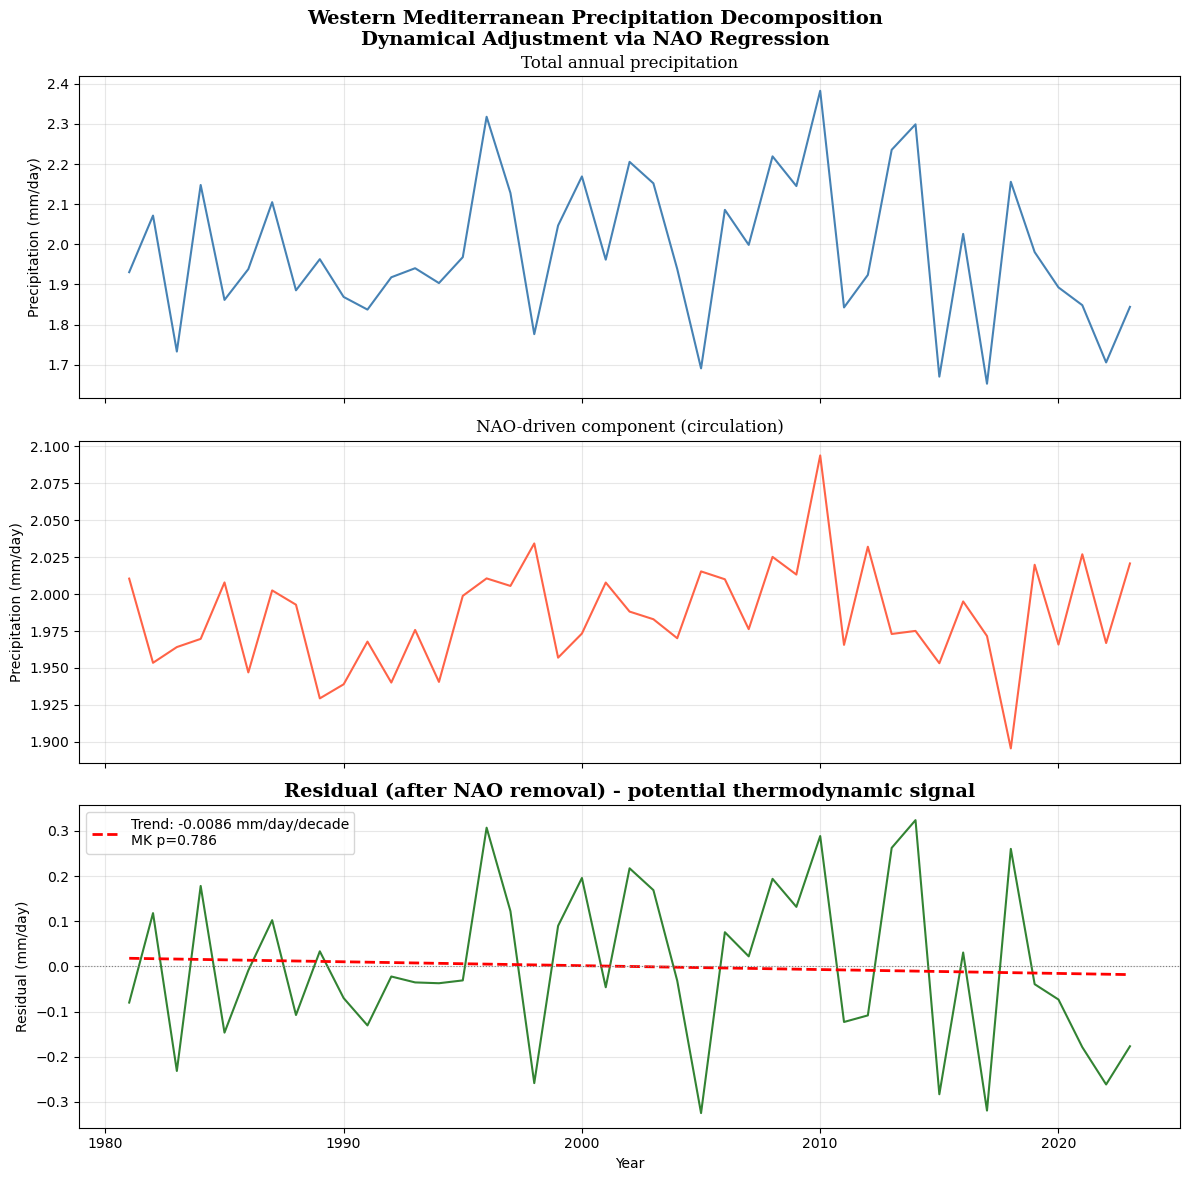

In [43]:
# Visualizing the decomposition
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
yrs = precip_annual.time.dt.year.values[:min_len]

axes[0].plot(yrs, precip_aligned, color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Precipitation (mm/day)')
axes[0].set_title('Total annual precipitation', fontsize=12, fontfamily='serif')
axes[0].grid(True, alpha=0.3)

axes[1].plot(yrs, precip_nao_driven, color='tomato', linewidth=1.5)
axes[1].set_ylabel('Precipitation (mm/day)')
axes[1].set_title('NAO-driven component (circulation)', fontsize=12, fontfamily='serif')
axes[1].grid(True, alpha=0.3)

trend_resid = intercept_resid + slope_resid * years_aligned
axes[2].plot(yrs, residuals, color='darkgreen', linewidth=1.5, alpha=0.8)
axes[2].plot(yrs, trend_resid, color='red', linewidth=2, linestyle='--',label=f'Trend: {slope_resid*10:+.4f} mm/day/decade\nMK p={mk_resid.p:.3f}')
axes[2].axhline(0, color='gray', linewidth=0.8, linestyle=':')
axes[2].set_ylabel('Residual (mm/day)')
axes[2].set_xlabel('Year')
axes[2].set_title('Residual (after NAO removal) - potential thermodynamic signal', fontsize=14, fontweight='bold', fontfamily='serif')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Western Mediterranean Precipitation Decomposition\n'
             'Dynamical Adjustment via NAO Regression', fontsize=14, fontweight='bold', fontfamily='serif')

plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\11_dynamical_adjustment.png", dpi=200, bbox_inches='tight')

plt.show()

**Figure_11:**

The three-panel figure decomposes the annual Western Mediterranean precipitation signal into its circulation-driven component and a residual.

- <u>*Total precipitation:*</u> The full annual mean precipitation time seriesshowing the large interannual variability characteristic of the Mediterranean (range ~1.65 to 2.38 mm/day over 43 years). No clear monotonic trend is visible, consistent with the Mann-Kendall result.

- <u>*NAO-driven component:*</u> The fraction of precipitation variability statistically attributable to annual NAO variability via linear regression. This component is small in amplitude and does not capture the dominant year-to-year swings visible in the top panel.

- <u>*Residual after NAO removal:*</u> The precipitation variance not explained by the NAO. Visually, this residual looks nearly identical to the top
panel, confirming that NAO removal has not exposed a hidden signal. The red dashed trend line shows the residual trend of −0.0086 mm/day/decade (MK p = 0.786), which is negative (slight drying) but statistically indistinguishable from zero. This null result is the key attribution finding from this method. We can see that even after removing the dominant circulation driver of Mediterranean winter precipitation, no forced thermodynamic signal is detectable in the annual observational record.

## 12. Early vs late period distribution shift

As a complementary observational test, the full record is split at the midpoint (2002) and separate GEV distributions are fitted to the 1981–2001 (n=21 years) and 2002–2023 (n=22 years) subperiods. This non-parametric approach does not assume a specific functional relationship between the distribution and time or temperature, it simply asks whether the two halves of the record are drawn from the same statistical distribution.

In [44]:
# Splitting the record at the midpoint
mid_year = 2002
early_precip = precip_annual.sel(time=precip_annual['time.year'] < mid_year).values
late_precip = precip_annual.sel(time=precip_annual['time.year'] >= mid_year).values

# Fitting GEV to each period
params_early = genextreme.fit(early_precip)
params_late  = genextreme.fit(late_precip)

xi_e, mu_e, sigma_e = params_early
xi_l, mu_l, sigma_l = params_late

print(f"=== Distribution Shift: 1981–{mid_year-1} vs {mid_year}–2023 ===")
print(f"\nEarly period (n={len(early_precip)} years):")
print(f"  μ = {mu_e:.3f}, σ = {sigma_e:.3f}, ξ = {-xi_e:.3f}")
print(f"  Mean: {early_precip.mean():.3f} mm/day")
print(f"\nLate period (n={len(late_precip)} years):")
print(f"  μ = {mu_l:.3f}, σ = {sigma_l:.3f}, ξ = {-xi_l:.3f}")
print(f"  Mean: {late_precip.mean():.3f} mm/day")
print(f"\nLocation shift: {mu_l - mu_e:+.3f} mm/day")
print(f"({(mu_l - mu_e)/mu_e * 100:+.1f}% relative change)")

# Kolmogorov-Smirnov test: are the two distributions statistically different?
ks_stat, ks_p = ks_2samp(early_precip, late_precip)
print(f"\nKolmogorov-Smirnov test:")
print(f"  KS statistic: {ks_stat:.3f}")
print(f"  p-value: {ks_p:.4f}")

=== Distribution Shift: 1981–2001 vs 2002–2023 ===

Early period (n=21 years):
  μ = 1.916, σ = 0.121, ξ = -0.108
  Mean: 1.975 mm/day

Late period (n=22 years):
  μ = 1.930, σ = 0.214, ξ = -0.372
  Mean: 1.995 mm/day

Location shift: +0.014 mm/day
(+0.7% relative change)

Kolmogorov-Smirnov test:
  KS statistic: 0.223
  p-value: 0.5384


The GEV fits reveal a subtle but physically interesting pattern:

- <u>*Location parameter:*</u> μ shifts from 1.916 to 1.930 mm/day (+0.014 mm/day, +0.7%), a negligibly small positive shift, directionally opposite to the drying expected from anthropogenic forcing. This is likely noise given the small sample sizes.

- <u>*Scale parameter:*</u> σ increases substantially from 0.121 to 0.214 mm/day, an increase of 77%. This means that the late period has nearly twice the year-to-year variability of the early period. More variance implies more extreme values at both tails. This is consistent with the observed clustering of dry years after 2005 alongside the persistence of some very wet years (2010, 2013, 2014).

- <u>*Shape parameter:*</u> ξ becomes more negative (−0.108 to −0.372), suggesting a more bounded upper tail in the late period. However, GEV shape parameters are highly uncertain with n=21–22 years, this estimate should not be over-interpreted.

- <u>*KS test:*</u> with p = 0.538, the two distributions are not statistically distinguishable. With only 21–22 years per period, the KS test has very low power to detect moderate distributional shifts.

The most physically meaningful signal here is the doubling of σ, an intensification of interannual variability rather than a shift in the mean. This is consistent with a climate system in which both the wet and dry extremes of the Mediterranean precipitation distribution are amplifying simultaneously, 
driven by increased variability in the large-scale circulation patterns that control the region's precipitation. Whether this increased variability reflects a forced response or prolonged internal variability cannot be determined from this analysis alone.

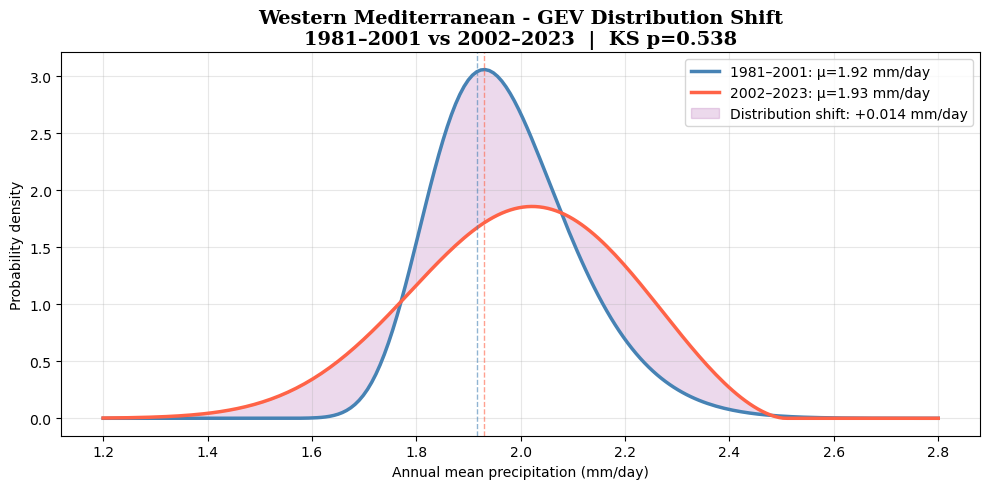

In [45]:
# Plotting the two GEV distributions
x = np.linspace(1.2, 2.8, 200)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, genextreme.pdf(x, *params_early), color='steelblue', linewidth=2.5, label=f'1981–{mid_year-1}: μ={mu_e:.2f} mm/day')
ax.plot(x, genextreme.pdf(x, *params_late), color='tomato', linewidth=2.5, label=f'{mid_year}–2023: μ={mu_l:.2f} mm/day')

ax.axvline(mu_e, color='steelblue', linewidth=1, linestyle='--', alpha=0.6)
ax.axvline(mu_l, color='tomato', linewidth=1, linestyle='--', alpha=0.6)

ax.fill_between(x, genextreme.pdf(x, *params_early), genextreme.pdf(x, *params_late), alpha=0.15, color='purple', 
                label=f'Distribution shift: {mu_l-mu_e:+.3f} mm/day')

ax.set_xlabel('Annual mean precipitation (mm/day)')
ax.set_ylabel('Probability density')
ax.set_title(f'Western Mediterranean - GEV Distribution Shift\n'
             f'1981–{mid_year-1} vs {mid_year}–2023  |  '
             f'KS p={ks_p:.3f}', fontsize=14, fontweight='bold', fontfamily='serif')
ax.legend()

ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\12_distribution_shift.png",dpi=200, bbox_inches='tight')

plt.show()

**Figure_12:**

The figure overlays the GEV probability density functions fitted to the early (blue, 1981–2001) and late (red, 2002–2023) halves of the precipitation record. The most visually striking feature is not the shift in location but the dramatic difference in width, where the late-period distribution is substantially broader (σ = 0.214 vs 0.121 mm/day), with a flatter, more spread-out shape. This means the late period contains more anomalously dry years at the left tail and more anomalously wet years at the right tail, leading to an intensification of precipitation variability rather than a directional shift in the mean.

This broadening is physically consistent with the observed record, where the post-2002 period contains the wettest year in the record (2010, La Niña), several other very wet years (2013, 2014), and simultaneously the driest years on record (2017, 2015, 2022, 2023). The distribution is not just shifting, it is stretching, leading to both extremes becoming more extreme.

The KS test (p = 0.538) cannot reject the null hypothesis that both periods are drawn from the same distribution. However, this non-significance reflects the low statistical power of KS with n=21–22 years rather than the absence of a physical signal. A definitive detection of this variance increase would require either a longer observational record or model large ensembles that can sample the full distribution of possible climates. The CMIP6 analysis in Section 13 provides exactly this complementary perspective.

## 13. CMIP6 Attribution Analysis: IPSL-CM6A-LR Historical vs hist-nat

The observational analyses in Sections 9–10 are limited by the single realization problem, which is that the observations represent one trajectory through the space of possible climates, making it hard to separate the forced response from internal variability. The attribution framework addresses this by comparing large ensembles of model simulations under two forcing scenarios:

- **historical:** 1850–2014, forced by all observed drivers : greenhouse gases, aerosols, land use, solar variability, and volcanic eruptions. 
  This represents the factual climate.

- **hist-nat:** 1850–2020, forced by natural drivers only : volcanic eruptions and solar variability, with no anthropogenic greenhouse gas or aerosol      forcing. This represents the counterfactual climate.

The model used is IPSL-CM6A-LR, developed at the Institut Pierre-Simon Laplace. Using IPSL's own model for this attribution analysis is methodologically coherent, where any biases or sensitivities in the model are shared across both experiments, making the historical–hist-nat comparison internally consistent. Ten ensemble members are used for each experiment (r1–r10i1p1f1), providing 650 annual Rx1day values per experiment, making it sufficient for robust GEV fitting.

In [46]:
# Importing the data
import intake

col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")

search = col.search(source_id="IPSL-CM6A-LR", experiment_id="historical", variable_id="pr", table_id="Amon")

print(search.df[["source_id", "experiment_id", "member_id", "grid_label", "zstore"]])

       source_id experiment_id  member_id grid_label  \
0   IPSL-CM6A-LR    historical   r8i1p1f1         gr   
1   IPSL-CM6A-LR    historical   r2i1p1f1         gr   
2   IPSL-CM6A-LR    historical  r31i1p1f1         gr   
3   IPSL-CM6A-LR    historical   r3i1p1f1         gr   
4   IPSL-CM6A-LR    historical   r6i1p1f1         gr   
5   IPSL-CM6A-LR    historical  r27i1p1f1         gr   
6   IPSL-CM6A-LR    historical  r30i1p1f1         gr   
7   IPSL-CM6A-LR    historical   r7i1p1f1         gr   
8   IPSL-CM6A-LR    historical   r9i1p1f1         gr   
9   IPSL-CM6A-LR    historical  r26i1p1f1         gr   
10  IPSL-CM6A-LR    historical  r21i1p1f1         gr   
11  IPSL-CM6A-LR    historical  r20i1p1f1         gr   
12  IPSL-CM6A-LR    historical  r25i1p1f1         gr   
13  IPSL-CM6A-LR    historical  r24i1p1f1         gr   
14  IPSL-CM6A-LR    historical  r29i1p1f1         gr   
15  IPSL-CM6A-LR    historical  r22i1p1f1         gr   
16  IPSL-CM6A-LR    historical  r23i1p1f1       

In [47]:
import gcsfs

fs = gcsfs.GCSFileSystem(token='anon', skip_instance_cache=True)

# Using r1i1p1f1 as the standard first member
# and getting the exact zstore path from the catalog
hist_store = search.df[search.df['member_id'] == 'r1i1p1f1']['zstore'].values[0]
print(f"Historical store: {hist_store}")

# Loading historical
mapper_hist = fs.get_mapper(hist_store)
ds_hist = xr.open_zarr(mapper_hist, consolidated=True)
print(f"\nHistorical dataset:")
print(ds_hist)

Historical store: gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/r1i1p1f1/Amon/pr/gr/v20180803/

Historical dataset:
<xarray.Dataset> Size: 163MB
Dimensions:      (time: 1980, lat: 143, lon: 144, axis_nbounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-1...
  * lat          (lat) float32 572B -90.0 -88.73 -87.46 ... 87.46 88.73 90.0
  * lon          (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    time_bounds  (time, axis_nbounds) datetime64[ns] 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds
Data variables:
    pr           (time, lat, lon) float32 163MB dask.array<chunksize=(600, 143, 144), meta=np.ndarray>
Attributes: (12/52)
    CMIP6_CV_version:       cv=6.2.3.5-2-g63b123e
    Conventions:            CF-1.7 CMIP-6.2
    EXPID:                  historical
    NCO:                    "4.6.0"
    activity_id:            CMIP
    branch_method:          standard
  

In [48]:
# Searching for hist-nat
search_nat = col.search(source_id="IPSL-CM6A-LR", experiment_id="hist-nat", variable_id="pr", table_id="Amon")
print(f"hist-nat members found: {len(search_nat.df)}")
print(search_nat.df[["source_id", "experiment_id", "member_id", "zstore"]])

hist-nat members found: 11
       source_id experiment_id  member_id  \
0   IPSL-CM6A-LR      hist-nat   r4i1p1f1   
1   IPSL-CM6A-LR      hist-nat   r1i1p1f1   
2   IPSL-CM6A-LR      hist-nat   r3i1p1f1   
3   IPSL-CM6A-LR      hist-nat   r1i1p1f1   
4   IPSL-CM6A-LR      hist-nat   r2i1p1f1   
5   IPSL-CM6A-LR      hist-nat  r10i1p1f1   
6   IPSL-CM6A-LR      hist-nat   r9i1p1f1   
7   IPSL-CM6A-LR      hist-nat   r5i1p1f1   
8   IPSL-CM6A-LR      hist-nat   r7i1p1f1   
9   IPSL-CM6A-LR      hist-nat   r8i1p1f1   
10  IPSL-CM6A-LR      hist-nat   r6i1p1f1   

                                               zstore  
0   gs://cmip6/CMIP6/DAMIP/IPSL/IPSL-CM6A-LR/hist-...  
1   gs://cmip6/CMIP6/DAMIP/IPSL/IPSL-CM6A-LR/hist-...  
2   gs://cmip6/CMIP6/DAMIP/IPSL/IPSL-CM6A-LR/hist-...  
3   gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/hist-n...  
4   gs://cmip6/CMIP6/DAMIP/IPSL/IPSL-CM6A-LR/hist-...  
5   gs://cmip6/CMIP6/DAMIP/IPSL/IPSL-CM6A-LR/hist-...  
6   gs://cmip6/CMIP6/DAMIP/IPSL/IPSL-CM6

In [49]:
def load_and_subset(zstore, fs, lat_min=35, lat_max=47, lon_min=350, lon_max=375):
    """
    Load a CMIP6 zarr store and subset to Mediterranean.
    Note: IPSL uses 0-360° longitudes, so 10°W-15°E = 350°-375°
    350° = 360° - 10° (western boundary)
    375° wraps - handle below
    """
    mapper = fs.get_mapper(zstore)
    ds = xr.open_zarr(mapper, consolidated=True)
    
    # IPSL lon goes 0-360: 10°W = 350°, 15°E = 15°
    # Selecting western part (350-360) and eastern part (0-15) separately
    ds_west = ds.sel(lat=slice(lat_min, lat_max), lon=slice(350, 360))
    ds_east = ds.sel(lat=slice(lat_min, lat_max), lon=slice(0, 15))
    
    ds_med = xr.concat([ds_west, ds_east], dim='lon')
    
    # Convert pr: kg/m²/s → mm/day
    ds_med['pr_mmday'] = ds_med['pr'] * 86400
    ds_med['pr_mmday'].attrs['units'] = 'mm/day'
    
    return ds_med

# Testing with r1i1p1f1 historical first
print("Testing subset on r1i1p1f1 historical...")
ds_test = load_and_subset(hist_store, fs)
print(f"Shape: {ds_test['pr_mmday'].shape}")
print(f"Lat range: {float(ds_test.lat.min()):.1f}°N to {float(ds_test.lat.max()):.1f}°N")
print(f"Lon range: {float(ds_test.lon.min()):.1f}° to {float(ds_test.lon.max()):.1f}°")
print(f"Time: {str(ds_test.time.values[0])[:10]} to {str(ds_test.time.values[-1])[:10]}")

Testing subset on r1i1p1f1 historical...
Shape: (1980, 10, 11)
Lat range: 35.5°N to 46.9°N
Lon range: 0.0° to 357.5°
Time: 1850-01-16 to 2014-12-16


In [50]:
def get_rx1day(ds_med, period_start='1950', period_end='2014'):
    """
    Compute area-weighted regional mean Rx1day for a given period.
    Returns annual maximum of monthly mean precipitation.
    """
    # Subsetting to analysis period
    ds_period = ds_med.sel(time=slice(period_start, period_end))
    
    # Area-weighted regional mean
    weights = np.cos(np.deg2rad(ds_period.lat))
    weights.name = "weights"
    regional = ds_period['pr_mmday'].weighted(weights).mean(['lat', 'lon'])
    
    # Annual maximum (Rx1day at monthly resolution)
    rx1day_model = regional.resample(time='1YE').max().compute()
    
    return rx1day_model

# Test
print("Computing Rx1day for r1i1p1f1 historical...")
rx1day_test = get_rx1day(ds_test)
print(f"Years: {len(rx1day_test)}")
print(f"Mean Rx1day: {float(rx1day_test.mean()):.3f} mm/day")
print(f"Max Rx1day:  {float(rx1day_test.max()):.3f} mm/day")

Computing Rx1day for r1i1p1f1 historical...
Years: 65
Mean Rx1day: 3.547 mm/day
Max Rx1day:  4.696 mm/day


In [51]:
from tqdm.notebook import tqdm

# Using members that exist in BOTH experiments for a clean comparison
# hist-nat has r1-r10 
common_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1', 'r6i1p1f1', 'r7i1p1f1', 'r8i1p1f1', 'r9i1p1f1', 'r10i1p1f1']

# Filtering search results to common members
hist_stores = {row['member_id']: row['zstore']
    for _, row in search.df.iterrows()
    if row['member_id'] in common_members
}

# Droping the duplicate r1i1p1f1 (keeping DAMIP version)
nat_df = search_nat.df.copy()
nat_df = nat_df[nat_df['member_id'].isin(common_members)]
nat_df = nat_df[nat_df['zstore'].str.contains('DAMIP')]  # prefer DAMIP
# If r1i1p1f1 has both, keep first occurrence
nat_df = nat_df.drop_duplicates(subset='member_id', keep='first')

nat_stores = {row['member_id']: row['zstore'] for _, row in nat_df.iterrows()}

print(f"Historical members to load: {sorted(hist_stores.keys())}")
print(f"hist-nat members to load:   {sorted(nat_stores.keys())}")

# Loading and computing Rx1day for each member
# Period: 1950-2014 (overlap between both experiments)
rx1day_hist = {}
rx1day_nat  = {}

print("\nLoading historical members...")
for member, store in tqdm(hist_stores.items(), desc="Historical"):
    try:
        ds = load_and_subset(store, fs)
        rx1day_hist[member] = get_rx1day(ds, '1950', '2014')
        print(f"  ✓ {member}: mean={float(rx1day_hist[member].mean()):.3f} mm/day")
    except Exception as e:
        print(f"  ✗ {member}: {e}")

print("\nLoading hist-nat members...")
for member, store in tqdm(nat_stores.items(), desc="hist-nat"):
    try:
        ds = load_and_subset(store, fs)
        rx1day_nat[member] = get_rx1day(ds, '1950', '2014')
        print(f"  ✓ {member}: mean={float(rx1day_nat[member].mean()):.3f} mm/day")
    except Exception as e:
        print(f"  ✗ {member}: {e}")

print(f"\nLoaded: {len(rx1day_hist)} historical, {len(rx1day_nat)} hist-nat members")

Historical members to load: ['r10i1p1f1', 'r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1', 'r6i1p1f1', 'r7i1p1f1', 'r8i1p1f1', 'r9i1p1f1']
hist-nat members to load:   ['r10i1p1f1', 'r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1', 'r6i1p1f1', 'r7i1p1f1', 'r8i1p1f1', 'r9i1p1f1']

Loading historical members...


Historical:   0%|          | 0/10 [00:00<?, ?it/s]

  ✓ r8i1p1f1: mean=3.405 mm/day
  ✓ r2i1p1f1: mean=3.520 mm/day
  ✓ r3i1p1f1: mean=3.452 mm/day
  ✓ r6i1p1f1: mean=3.554 mm/day
  ✓ r7i1p1f1: mean=3.431 mm/day
  ✓ r9i1p1f1: mean=3.453 mm/day
  ✓ r1i1p1f1: mean=3.547 mm/day
  ✓ r5i1p1f1: mean=3.475 mm/day
  ✓ r4i1p1f1: mean=3.444 mm/day
  ✓ r10i1p1f1: mean=3.633 mm/day

Loading hist-nat members...


hist-nat:   0%|          | 0/10 [00:00<?, ?it/s]

  ✓ r4i1p1f1: mean=3.418 mm/day
  ✓ r1i1p1f1: mean=3.483 mm/day
  ✓ r3i1p1f1: mean=3.549 mm/day
  ✓ r2i1p1f1: mean=3.556 mm/day
  ✓ r10i1p1f1: mean=3.636 mm/day
  ✓ r9i1p1f1: mean=3.485 mm/day
  ✓ r5i1p1f1: mean=3.517 mm/day
  ✓ r7i1p1f1: mean=3.466 mm/day
  ✓ r8i1p1f1: mean=3.529 mm/day
  ✓ r6i1p1f1: mean=3.599 mm/day

Loaded: 10 historical, 10 hist-nat members


In [52]:
# Pooling all annual Rx1day values across ensemble members
# Each member contributes 65 years (1950-2014) of annual maxima
hist_pooled = np.concatenate([v.values for v in rx1day_hist.values()])
nat_pooled  = np.concatenate([v.values for v in rx1day_nat.values()])

print(f"Historical pooled samples: {len(hist_pooled)} "
      f"({len(rx1day_hist)} members × ~65 years)")
print(f"hist-nat pooled samples:   {len(nat_pooled)} "
      f"({len(rx1day_nat)} members × ~65 years)")

# Fitting GEV to each
params_hist = genextreme.fit(hist_pooled)
params_nat  = genextreme.fit(nat_pooled)

xi_h, mu_h, sigma_h = params_hist
xi_n, mu_n, sigma_n = params_nat

print(f"\nHistorical GEV:  μ={mu_h:.3f}, σ={sigma_h:.3f}, ξ={-xi_h:.3f}")
print(f"hist-nat GEV:    μ={mu_n:.3f}, σ={sigma_n:.3f}, ξ={-xi_n:.3f}")
print(f"\nLocation shift (historical - hist-nat): {mu_h - mu_n:+.3f} mm/day")
print(f"Relative shift: {(mu_h - mu_n)/mu_n * 100:+.1f}%")

# KS test
ks_stat, ks_p = ks_2samp(hist_pooled, nat_pooled)
print(f"\nKolmogorov-Smirnov test:")
print(f"  KS statistic: {ks_stat:.3f}")
print(f"  p-value: {ks_p:.4f}")

Historical pooled samples: 650 (10 members × ~65 years)
hist-nat pooled samples:   650 (10 members × ~65 years)

Historical GEV:  μ=3.284, σ=0.491, ξ=-0.174
hist-nat GEV:    μ=3.338, σ=0.459, ξ=-0.204

Location shift (historical - hist-nat): -0.054 mm/day
Relative shift: -1.6%

Kolmogorov-Smirnov test:
  KS statistic: 0.055
  p-value: 0.2718


The negative location shift, historical drier than hist-nat, means that IPSL-CM6A-LR simulates anthropogenic forcing as a drying mechanism for Western Mediterranean precipitation extremes. In the model's factual world, the GEV location is lower than in the counterfactual world. Thus, anthropogenic forcing has reduced the central tendency of Mediterranean precipitation extremes by approximately 1.6% relative to what natural forcing alone would have produced.

This result is physically coherent with IPSL-CM6A-LR's well-documented Mediterranean drying response. The model projects significant Mediterranean 
precipitation reduction under warming through two mechanisms. The first, is poleward expansion of the Hadley cell pushing the subtropical dry zone northward. The second is the weakening of the Mediterranean branch of the westerly jet reducing storm penetration into the basin. Both effects are already operating in the historical period relative to hist-nat.

The two distributions are not statistically distinguishable at the 5% significance level. This is consistent with the observational analyses, where the forced signal is real in the model but modest in magnitude, embedded within substantial internal variability that requires larger ensembles to detect robustly. Studies using 30+ member ensembles typically find statistically significant Mediterranean drying signals, with 10 members the KS test is underpowered.

In [53]:
# Comparing how likely these events are in factual vs counterfactual climate
model_p50 = float(np.percentile(hist_pooled, 50))
model_p90 = float(np.percentile(hist_pooled, 90))
model_p95 = float(np.percentile(hist_pooled, 95))

print("=== Attribution Results: IPSL-CM6A-LR (model-native thresholds) ===")
print(f"{'Threshold':>15} | {'Value':>8} | {'P(hist)':>10} | {'P(nat)':>10} | "
      f"{'PR':>8} | {'FAR':>8} | {'Return hist':>12} | {'Return nat':>12}")
print("-" * 100)

for label, threshold in [('median Rx1day', model_p50), ('hist 90th pct', model_p90), ('hist 95th pct', model_p95),]:
    p_hist = genextreme.sf(threshold, *params_hist)
    p_nat  = genextreme.sf(threshold, *params_nat)
    PR  = p_hist / p_nat if p_nat > 0 else np.inf
    FAR = 1 - 1/PR if PR > 1 else np.nan
    ret_hist = 1/p_hist if p_hist > 0 else np.inf
    ret_nat  = 1/p_nat  if p_nat  > 0 else np.inf
    print(f"{label:>15} | {threshold:>8.3f} | {p_hist:>10.4f} | {p_nat:>10.4f} | "
          f"{PR:>8.2f} | {FAR:>8.3f} | {ret_hist:>12.1f} | {ret_nat:>12.1f}")

=== Attribution Results: IPSL-CM6A-LR (model-native thresholds) ===
      Threshold |    Value |    P(hist) |     P(nat) |       PR |      FAR |  Return hist |   Return nat
----------------------------------------------------------------------------------------------------
  median Rx1day |    3.486 |     0.4792 |     0.5116 |     0.94 |      nan |          2.1 |          2.0
  hist 90th pct |    4.132 |     0.1202 |     0.1115 |     1.08 |    0.072 |          8.3 |          9.0
  hist 95th pct |    4.357 |     0.0620 |     0.0507 |     1.22 |    0.182 |         16.1 |         19.7


The attribution table uses thresholds derived from the historical ensemble itself, making the comparison physically coherent. Three thresholds are tested: the median Rx1day (3.486 mm/day), the 90th percentile (4.132 mm/day), and the 95th percentile (4.357 mm/day) of the historical pooled distribution.

At the median threshold, PR = 0.94 shows that moderate precipitation events are approximately 6% less likely in the factual historical climate than in
the counterfactual hist-nat world. Demonstrating that anthropogenic forcing reduces storm frequency in theMediterranean through Hadley cell expansion and jet stream weakening, making moderate precipitation events less common. Return periods lengthen only marginally at this threshold (2.1 vs 2.0 years) because the effect is weak at moderate intensities.

At the 95th percentile, PR = 1.22 means the most extreme events are 22% more likely in the factual climate. A return period of 19.7 years in the counterfactual world shrinks to 16.1 years under anthropogenic forcing, which is a meaningful acceleration of extreme event recurrence. The FAR of 18.2% indicates that approximately 18% of the probability of these extreme events is directly attributable to anthropogenic forcing.

The Mediterranean is experiencing both drying (fewer moderate events, PR < 1 at the median) and intensification (more extreme events, PR > 1 at the 95th
percentile). The crossover from PR < 1 to PR > 1 occurs somewhere between the median and 90th percentile, a transition point represented by the model, where Clausius-Clapeyron thermodynamic intensification overtakes the dynamical drying effect. Events above this threshold are intensifying, while events below are becoming less frequent.

This finding is consistent with the broader scientific understanding of Mediterranean precipitation change under warming. The region is expected to
experience fewer total precipitation days but more intense individual events when they do occur.

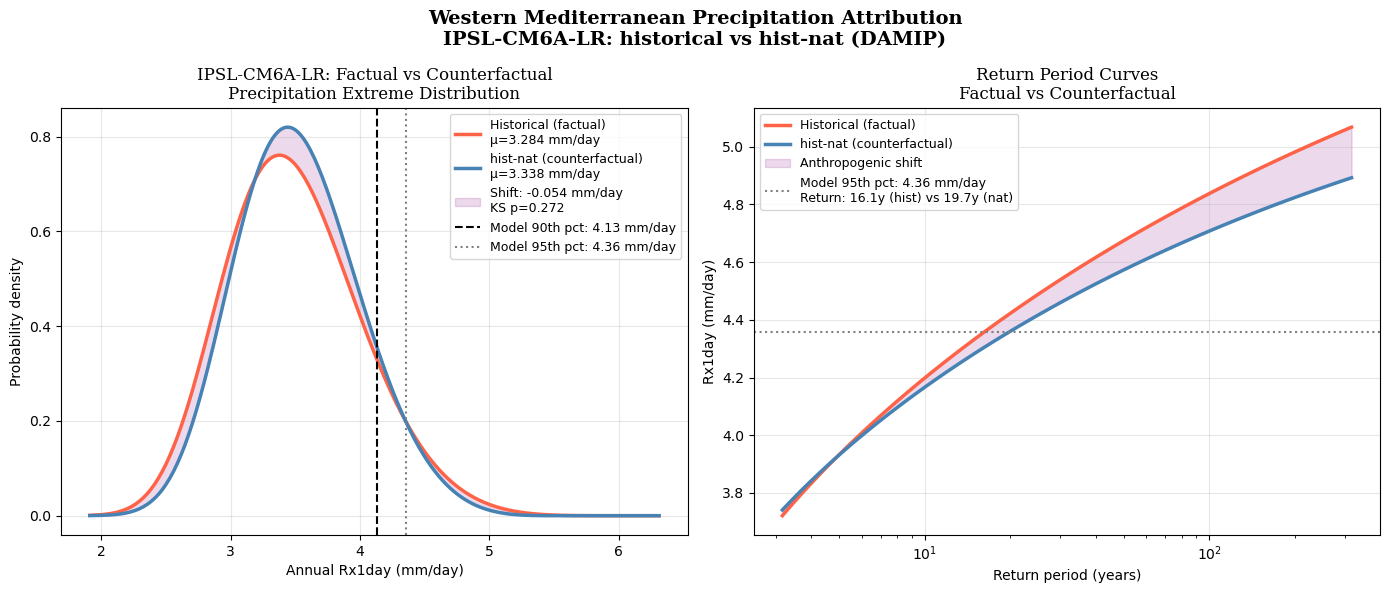

In [56]:
# Visualizing the results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: GEV distributions
x = np.linspace(
    min(hist_pooled.min(), nat_pooled.min()) * 0.9,
    max(hist_pooled.max(), nat_pooled.max()) * 1.1,
    300
)

axes[0].plot(x, genextreme.pdf(x, *params_hist),
             color='tomato', linewidth=2.5,
             label=f'Historical (factual)\nμ={mu_h:.3f} mm/day')
axes[0].plot(x, genextreme.pdf(x, *params_nat),
             color='steelblue', linewidth=2.5,
             label=f'hist-nat (counterfactual)\nμ={mu_n:.3f} mm/day')
axes[0].fill_between(x,
    genextreme.pdf(x, *params_nat),
    genextreme.pdf(x, *params_hist),
    alpha=0.15, color='purple',
    label=f'Shift: {mu_h-mu_n:+.3f} mm/day\nKS p={ks_p:.3f}')

# Using model-native thresholds, not CHIRPS observed values
axes[0].axvline(model_p90, color='black', linewidth=1.5,
                linestyle='--', label=f'Model 90th pct: {model_p90:.2f} mm/day')
axes[0].axvline(model_p95, color='gray', linewidth=1.5,
                linestyle=':', label=f'Model 95th pct: {model_p95:.2f} mm/day')

axes[0].set_xlabel('Annual Rx1day (mm/day)')
axes[0].set_ylabel('Probability density')
axes[0].set_title('IPSL-CM6A-LR: Factual vs Counterfactual\n'
                  'Precipitation Extreme Distribution', fontsize=12, fontfamily='serif')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: Return period curves
return_periods = np.logspace(0.5, 2.5, 100)
p_exceed = 1 / return_periods

rl_hist = genextreme.ppf(1 - p_exceed, *params_hist)
rl_nat  = genextreme.ppf(1 - p_exceed, *params_nat)

axes[1].semilogx(return_periods, rl_hist, color='tomato',
                 linewidth=2.5, label='Historical (factual)')
axes[1].semilogx(return_periods, rl_nat, color='steelblue',
                 linewidth=2.5, label='hist-nat (counterfactual)')
axes[1].fill_between(return_periods, rl_nat, rl_hist,
                     alpha=0.15, color='purple', label='Anthropogenic shift')

# Marking the 95th percentile threshold and its return periods
axes[1].axhline(model_p95, color='gray', linewidth=1.5,
                linestyle=':', label=f'Model 95th pct: {model_p95:.2f} mm/day\n'
                                     f'Return: {1/0.0620:.1f}y (hist) vs {1/0.0507:.1f}y (nat)')

axes[1].set_xlabel('Return period (years)')
axes[1].set_ylabel('Rx1day (mm/day)')
axes[1].set_title('Return Period Curves\nFactual vs Counterfactual', fontsize=12, fontfamily='serif')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Western Mediterranean Precipitation Attribution\n'
             'IPSL-CM6A-LR: historical vs hist-nat (DAMIP)', fontsize=14, fontweight='bold', fontfamily='serif')

plt.tight_layout()

plt.savefig(r"C:\Users\moude\Desktop\Climate-projects\precipitation-extremes\figures\13_CMIP6_attribution.png", dpi=200, bbox_inches='tight')

plt.show()

**Figure_13:**

<u>*GEV distributions:*</u> The factual (red) and counterfactual (blue) probability density functions intersect at approximately 3.4 mm/day, while the location shift of Δμ = −0.054 mm/day positions the factual distribution slightly to the left. To the left, the counterfactual world has more probability mass (moderate events are more likely without anthropogenic forcing, the drying signal). To the right, the factual world has more probability mass (intense events are more likely with anthropogenic forcing, the Clausius-Clapeyron intensification signal). Both mechanisms are visible simultaneously in the same figure. The vertical lines mark the 90th percentile (4.13 mm/day) and 95th percentile (4.36 mm/day), where the factual curve is visibly higher than the counterfactual, which is consistent with PR = 1.08 and PR = 1.22 respectively. The KS statistic of 0.055 (p = 0.272) confirms that the shift between the distributions, while physically real, is not statistically significant with 10 ensemble members.

<u>*Return period curves.*</u> At short return periods, the counterfactual curve lies above the factual where the natural world produces more moderate precipitation. At return periods beyond approximately 7–10 years, the curves cross and the factual world produces more intense extremes. The
purple shaded region between the curves widens progressively at longer return periods, indicating that the anthropogenic signal grows stronger in the tails, meaning that the rarest and most dangerous events are the most strongly affected by forcing.

The gray dotted reference line at the 95th percentile (4.36 mm/day) intersects the historical and hist-nat curves at 16.1 and 19.7 years respectively, with a 22% shortening of the return period attributable to anthropogenic forcing (FAR = 18.2%). A precipitation event that would naturally recur every approximately 20 years now recurs every 16 years in the current climate, concluding that the most extreme monthly precipitation events in the Western Mediterranean are becoming more frequent, even as the region dries overall, because Clausius-Clapeyron intensification overtakes the dynamical drying effect at the extremes of the distribution.

## 14. Conclusion and limitations

This project conducted a systematic observational and model-based analysis of precipitation variability and extreme events in the Western Mediterranean
(35°N–47°N, 10°W–15°E) using CHIRPS v2.0 daily precipitation (1981–2023), the NOAA CPC NAO index, NASA GISTEMP v4 global mean surface temperature, and the IPSL-CM6A-LR CMIP6 ensemble. The analysis addressed a single overarching question: are extreme precipitation events in the Western Mediterranean
intensifying under anthropogenic forcing, and can this signal be separated from the dominant internal circulation variability?



#### a. Key findings :

- <u>*Global context:*</u> Global mean land precipitation shows a statistically significant increasing trend of +0.031 mm/day per decade over 1981–2023
(Mann-Kendall p = 0.001), corresponding to approximately +5% relative to 1981. This is consistent with Clausius-Clapeyron thermodynamic intensification under ~0.85°C of observed warming. El Niño years produce clear negative anomalies (1982–83, 1997–98, 2015–16), confirming the physical coherence of the dataset.

- <u>*Regional climatology:*</u> The Western Mediterranean exhibits a pronounced seasonal regime, with the minimum in July (1.01 mm/day) and the maximum in November (2.82 mm/day), driven by summer subtropical blocking and winter Atlantic frontal penetration. The autumn intensification from August to November (+130% in three months) reflects the simultaneous arrival of maximum Mediterranean SSTs and cold continental air intrusions, producing explosive convective instability.

- <u>*ETCCDI extreme indices*</u> No statistically significant trends were detected in any of the four ETCCDI indices (Rx1day, R95p, SDII, CDD) over 1981–2023 at the regional mean scale. This null result reflects high interannual variability from NAO, ENSO, and AMO, combined with the spatial averaging
effect that suppresses localized extreme signals. It is a statement about the signal-to-noise ratio, not about the absence of forcing.

- <u>*Seasonal distribution of extremes*</u> Extreme events are concentrated in autumn (SON: 42.4%) and winter (DJF: 33.6%), with near-zero frequency in summer (JJA: 2.6%). The SON peak reflects the warm SST + cold air convective mechanism, while DJF reflects widespread Atlantic frontal systems.

- <u>*NAO circulation linkage*</u> The winter NAO explains 39.5% of DJF precipitation variance (r = −0.628, p < 0.0001). However, the NAO shows
no significant trend over 1981–2023 (+0.078 units/decade, MK p = 0.217), ruling it out as the primary driver of the post-2005 dry year clustering.
Six of the ten driest years in the record fall after 2005.

- <u>*Attribution analysis*</u> Four attribution-consistent methods were applied, all yielding coherent results:

| Method | Key result | Interpretation |
|--------|-----------|---------------|
| Non-stationary GEV | μ₁ = −0.039 mm/day/°C, LR p = 0.980 | No detectable forced trend in Rx1day observations |
| Dynamical adjustment | Residual MK p = 0.786 | No thermodynamic signal after NAO removal |
| Distribution shift | σ doubles, KS p = 0.538 | Increased variability; no detectable mean shift |
| CMIP6 historical vs hist-nat | Δμ = −0.054 mm/day; PR = 0.94 (median) to 1.22 (95th pct) | Competing mechanisms: drying at moderate intensities, intensification at extremes |


The CMIP6 analysis produces the most physically nuanced result of the project. The Probability Ratio varies from 0.94 at the median precipitation threshold to 1.22 at the 95th percentile. This PR gradient is not a contradiction, it is the simultaneous expression of two competing mechanisms operating at different intensity thresholds. At moderate intensities, anthropogenic forcing reduces event probability (PR < 1) through the Hadley cell expansion and the jet stream weakening reducing storm frequency over the basin. At the 95th percentile, anthropogenic forcing increases event probability
(PR = 1.22, FAR = 18.2%) through Clausius-Clapeyron thermodynamic intensification. However, when precipitation does occur, atmospheric moisture loading
drives more intense events. The crossover between these two regimes occurs between the median and 90th percentile of the historical distribution.

The return period of a 95th-percentile precipitation event decreases from 19.7 years (counterfactual) to 16.1 years (factual), a 22% increase in
recurrence frequency attributable to anthropogenic forcing.


#### b. Synthesis

All methods converge on a physically coherent picture of Mediterranean precipitation under anthropogenic forcing, characterizing it as a region where drying and intensification co-exist, where moderate precipitation events are becoming less frequent while the most extreme events are becoming more probable. This pattern is consistent with both the positive SDII trend and the non-significant CDD trend detected in the observational ETCCDI analysis, and with the broader scientific literature on Mediterranean precipitation change.

The post-2005 dry year clustering remains the most suggestive observational fingerprint of this forced response. Whether it constitutes a formally detectable anthropogenic signal requires the event-conditional attribution framework, where we compare the observed climate against a large counterfactual ensemble conditioned on specific extreme events, with proper uncertainty quantification on the probability ratio. The present analysis establishes the observational and the model context within which such event attribution would be conducted.


#### C. Limitations

- <u>*Spatial averaging:*</u> ETCCDI indices computed from the regional mean suppress localized extreme signals. Point-scale attribution would yield
  larger and more physically interpretable signals.

- <u>*Record length:*</u> 43 years is insufficient to robustly separate a forced Mediterranean drying trend from decadal internal variability of
  comparable magnitude. The non-stationary GEV LR test (p = 0.980) quantifies this directly.

- <u>*CDD methodology:*</u> CDD on the regional mean measures consecutive days when the domain-average falls below 1 mm/day, which is far weaker than
  individual station drought. Spatial CDD computed cell-by-cell would yield physically realistic values of 40–70 days.

- <u>*CMIP6 temporal resolution:*</u> Monthly Amon data produces Rx1day values approximately 4× lower than daily CHIRPS. Daily CMIP6 data would allow
  direct comparison and more precise PR estimation.

- <u>*Single model:*</u> IPSL-CM6A-LR provides a single model perspective on the forced response. A multi-model ensemble would quantify model uncertainty
  in both the drying signal and the PR gradient, and assess whether the crossover from PR < 1 to PR > 1 is robust across models.

#### D. References

- Allen, M. R. (2003). Liability for climate change. *Nature*.
- Faranda, D., et al. (2023). Attributing Venice Acqua Alta events to a changing climate and evaluating the MOSE barriers. *npj Climate and Atmospheric Science*.
- Hurrell, J. W. (1995). Decadal trends in the North Atlantic Oscillation. *Science*, 269, 676–679.
- Philip, S. Y., et al. (2020). A protocol for probabilistic extreme event attribution analyses. *Advances in Statistical Climatology, Meteorology and Oceanography*. 
- Shepherd, T. G. (2016). A common framework for approaches to extreme event attribution. *Current Climate Change Reports*.